In [2]:
!pip install xgboost

In [3]:
!pip install shap>=0.46.0 

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, learning_curve

import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow import keras
from scipy.stats import wilcoxon, kruskal


In [2]:
BASE_DIR = r"C:\Users\emran\Desktop\UCL\Dissertation\Datasets"
OUTPUT_DIR = os.path.join(BASE_DIR, "Processed")
MODEL_DIR = os.path.join(BASE_DIR, "Models")
os.makedirs(MODEL_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Base directory: {BASE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model directory: {MODEL_DIR}")
print(f"Seed: {SEED}")

TensorFlow: 2.20.0
GPU available: False
Base directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets
Output directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed
Model directory: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Models
Seed: 42


In [3]:
df = pd.read_csv(os.path.join(OUTPUT_DIR, "Final Dataset_Hourly_2021 to 2024.csv"), index_col=0, parse_dates=True)

print(f"Shape: {df.shape}")
print(f"Range: {df.index.min()} to {df.index.max()}")
print(f"NaN: {df.isna().sum().sum()}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (35040, 24)
Range: 2021-01-02 00:00:00+00:00 to 2024-12-31 23:00:00+00:00
NaN: 0
Columns: ['generation_mw', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor', 'ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_generation_mw', 'total_generation_mw', 'renewables_pct', 'regime', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'wind_speed', 'lag_1h', 'lag_24h']


,generation_mw,capacity_mwp,ucl_mw,lcl_mw,capacity_factor,ssr,ssrd,fdir,d2m,t2m,...,total_generation_mw,renewables_pct,regime,hour_sin,hour_cos,doy_sin,doy_cos,wind_speed,lag_1h,lag_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2021-01-02 00:00:00+00:00,0.0,13503.21,0.0,0.0,0.0,9.999997e-16,0.0,0.0,1.287231,3.872885,...,23282.0,13.194743,Low (<25%),0.000000,1.000000,0.034422,0.999407,5.254196,0.0,0.0
2021-01-02 01:00:00+00:00,0.0,13503.21,0.0,0.0,0.0,9.999997e-16,0.0,0.0,1.212451,3.775867,...,22924.0,13.477142,Low (<25%),0.258819,0.965926,0.034422,0.999407,5.306569,0.0,0.0
2021-01-02 02:00:00+00:00,0.0,13503.21,0.0,0.0,0.0,9.999997e-16,0.0,0.0,1.150962,3.701990,...,22029.5,15.635852,Low (<25%),0.500000,0.866025,0.034422,0.999407,5.398961,0.0,0.0
2021-01-02 03:00:00+00:00,0.0,13503.21,0.0,0.0,0.0,9.999997e-16,0.0,0.0,1.101854,3.620539,...,21338.0,15.627050,Low (<25%),0.707107,0.707107,0.034422,0.999407,5.493072,0.0,0.0
2021-01-02 04:00:00+00:00,0.0,13503.21,0.0,0.0,0.0,9.999997e-16,0.0,0.0,1.013353,3.485282,...,20841.0,16.681061,Low (<25%),0.866025,0.500000,0.034422,0.999407,5.539453,0.0,0.0


In [4]:
#Defining features, targets, and hyperparameters
TARGET = 'generation_mw'

#Features for recurrent models (LSTM, BiLSTM, GRU, Stacked LSTM)
#Models will see a 24h window of past values
RECURRENT_FEATURES = ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'generation_mw']

#Features for XGBoost, Random Forest, Linear Regression, DNN
#Models see one row at a time (no sequence window)
TABULAR_FEATURES_1H = ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_1h']
TABULAR_FEATURES_24H = ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_24h']

#Columns used for post-prediction evaluation only
EVALUATION_ONLY = ['renewables_pct', 'regime', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor']

#Hyperparameters
WINDOW_SIZE = 24
BATCH_SIZE = 64
EPOCHS = 50
PATIENCE = 10
MC_PASSES = 100
CV_SPLITS = 5

In [5]:
print(f"Target: {TARGET}")
print(f"\nRecurrent features ({len(RECURRENT_FEATURES)}): {RECURRENT_FEATURES}")
print(f"\nTabular features 1h ({len(TABULAR_FEATURES_1H)}): {TABULAR_FEATURES_1H}")
print(f"\nTabular features 24h ({len(TABULAR_FEATURES_24H)}): {TABULAR_FEATURES_24H}")
print(f"\nEvaluation only columns: {EVALUATION_ONLY}")
print(f"\nHyperparameters training:")
print(f" Window size: {WINDOW_SIZE}")
print(f" Batch size: {BATCH_SIZE}")
print(f" Epochs: {EPOCHS}")
print(f" Early stopping patience: {PATIENCE}")
print(f" MC Dropout passes: {MC_PASSES}")
print(f" CV splits: {CV_SPLITS}")

Target: generation_mw

Recurrent features (14): ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'generation_mw']

Tabular features 1h (14): ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_1h']

Tabular features 24h (14): ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'lag_24h']

Evaluation only columns: ['renewables_pct', 'regime', 'capacity_mwp', 'ucl_mw', 'lcl_mw', 'capacity_factor']

Hyperparameters training:
 Window size: 24
 Batch size: 64
 Epochs: 50
 Early stopping patience: 10
 MC Dropout passes: 100
 CV splits: 5


In [6]:
#Train/val/test split
df_train = df[df.index.year.isin([2021, 2022])]
df_val = df[df.index.year == 2023]
df_test = df[df.index.year == 2024]

print(f"Train: {df_train.shape}, from {df_train.index.min()} to {df_train.index.max()}")
print(f"Val: {df_val.shape}, from {df_val.index.min()} to {df_val.index.max()}")
print(f"Test: {df_test.shape}, from {df_test.index.min()} to {df_test.index.max()}")
print(f"\nTotal: {len(df_train) + len(df_val) + len(df_test)}")
print(f"Train: {len(df_train)/len(df) * 100:.2f}%")
print(f"Val: {len(df_val)/len(df) * 100:.2f}%")
print(f"Test: {len(df_test)/len(df) * 100:.2f}%")

Train: (17496, 24), from 2021-01-02 00:00:00+00:00 to 2022-12-31 23:00:00+00:00
Val: (8760, 24), from 2023-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00
Test: (8784, 24), from 2024-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00

Total: 35040
Train: 49.93%
Val: 25.00%
Test: 25.07%


In [7]:
#Verify no data leakage
print(f"Train timestamps ends before Val starts: {df_train.index.max() < df_val.index.min()}")
print(f"Val timestamps ends before Test starts: {df_val.index.max() < df_test.index.min()}")

Train timestamps ends before Val starts: True
Val timestamps ends before Test starts: True


In [8]:
#Count regime distribution per split
for name, split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    counts = split['regime'].value_counts().reindex(['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)'])

    percentages = (counts / len(split) * 100).round(1)
    print(f"\n{name} ({len(split)} hours):")
    for regime, count in counts.items():
        print(f" {regime:<20} {count:>3} hours ({percentages[regime]:.1f})%")


Train (17496 hours):
 Low (<25%)           8385 hours (47.9)%
 Moderate (25-40%)    4992 hours (28.5)%
 High (> 40%)         4119 hours (23.5)%

Val (8760 hours):
 Low (<25%)           2943 hours (33.6)%
 Moderate (25-40%)    2392 hours (27.3)%
 High (> 40%)         3425 hours (39.1)%

Test (8784 hours):
 Low (<25%)           2475 hours (28.2)%
 Moderate (25-40%)    2391 hours (27.2)%
 High (> 40%)         3918 hours (44.6)%


In [9]:
#Applying StandardScaler on features (on train only)
all_model_features = RECURRENT_FEATURES + ['lag_1h', 'lag_24h']
feature_scaler = StandardScaler()
feature_scaler.fit(df_train[all_model_features])

train_scaled = df_train.copy()
val_scaled = df_val.copy()
test_scaled = df_test.copy()

for split, source in [(train_scaled, df_train), (val_scaled, df_val), (test_scaled, df_test)]:
    split[all_model_features] = feature_scaler.transform(source[all_model_features])

print(f"Train scaled feature statistics:")
print(train_scaled[all_model_features].describe().loc[['mean', 'std']].round(4).to_string())
print(f"\nVal scaled feature statistics:")
print(val_scaled[all_model_features].describe().loc[['mean', 'std']].round(4).to_string())
print(f"\nTest scaled feature statistics:")
print(test_scaled[all_model_features].describe().loc[['mean', 'std']].round(4).to_string())


Train scaled feature statistics:
      ssr  ssrd  fdir  d2m  t2m  u10  v10  tcc  wind_speed  hour_sin  hour_cos  doy_sin  doy_cos  generation_mw  lag_1h  lag_24h
mean  0.0  -0.0   0.0  0.0  0.0 -0.0  0.0  0.0         0.0      -0.0      -0.0     -0.0     -0.0           -0.0    -0.0      0.0
std   1.0   1.0   1.0  1.0  1.0  1.0  1.0  1.0         1.0       1.0       1.0      1.0      1.0            1.0     1.0      1.0

Val scaled feature statistics:
         ssr    ssrd    fdir     d2m     t2m     u10     v10     tcc  wind_speed  hour_sin  hour_cos  doy_sin  doy_cos  generation_mw  lag_1h  lag_24h
mean -0.0064 -0.0068 -0.0016  0.0922  0.0683  0.0278 -0.0037 -0.0198     -0.0191   -0.0000   -0.0000   0.0000   0.0019         0.0522  0.0522   0.0518
std   1.0040  1.0038  1.0248  0.9566  0.9580  1.0510  0.8989  1.0400      0.9286    1.0001    1.0001   0.9994   1.0007         1.0887  1.0887   1.0888

Test scaled feature statistics:
         ssr    ssrd    fdir     d2m     t2m     u10     v10  

In [10]:
#Separate target scaler - for target variable
target_scaler = StandardScaler()
target_scaler.fit(df_train[[TARGET]])

print(f"Target scaler fitted on training data:")
print(f" Mean: {target_scaler.mean_[0]:.2f} MW")
print(f" Std: {target_scaler.scale_[0]:.2f} MW")

Target scaler fitted on training data:
 Mean: 1431.25 MW
 Std: 2185.45 MW


In [11]:
#Defining and building 3D input arrays for recurrent models
def create_sequences(data, features, target, window_size, horizon):
    """
    Construct 3D sequential feature windows for recurrent models.

    Parameters:
        data: DataFrame with chronological DatetimeIndex
        features: List of columns used for input features
        target: Column name for the target variable
        window_size: Number of past timesteps in each input window
        horizon: Target forecast horizon offset (1 for 1h, 24 for 24h)
    
    Returns:
        X: 3D array of shape (num_samples, window_size, num_features)
        y: 1D array of shape (num_samples,)
        indices: Chronological timestamps corresponding to target
    """
    feature_values = data[features].values
    target_values = data[target].values
    X, y, indices = [], [], []

    for i in range(window_size, len(data) - horizon + 1):
        X.append(feature_values[i - window_size:i])
        y.append(target_values[i + horizon -1])
        indices.append(data.index[i + horizon -1])
    
    return np.array(X), np.array(y), pd.DatetimeIndex(indices)

print(f" Window size: {WINDOW_SIZE} hours")
print(f" Features per timestamp: {len(RECURRENT_FEATURES)}")
print(f" Output X shape per sample: ({WINDOW_SIZE}, {len(RECURRENT_FEATURES)})")

 Window size: 24 hours
 Features per timestamp: 14
 Output X shape per sample: (24, 14)


In [12]:
#Building sequences for 1-hour ahead
X_train_1h, y_train_1h, idx_train_1h = create_sequences(train_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=1)
X_val_1h, y_val_1h, idx_val_1h = create_sequences(val_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=1)
X_test_1h, y_test_1h, idx_test_1h = create_sequences(test_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=1)

print(f"Train: X={X_train_1h.shape}, y={y_train_1h.shape}")
print(f"Val: X={X_val_1h.shape}, y={y_val_1h.shape}")
print(f"Test: X={X_test_1h.shape}, y={y_test_1h.shape}")

Train: X=(17472, 24, 14), y=(17472,)
Val: X=(8736, 24, 14), y=(8736,)
Test: X=(8760, 24, 14), y=(8760,)


In [13]:
#Building sequences for 24-hour ahead
X_train_24h, y_train_24h, idx_train_24h = create_sequences(train_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=24)
X_val_24h, y_val_24h, idx_val_24h = create_sequences(val_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=24)
X_test_24h, y_test_24h, idx_test_24h = create_sequences(test_scaled, RECURRENT_FEATURES, TARGET, WINDOW_SIZE, horizon=24)

print(f"Train: X={X_train_24h.shape}, y={y_train_24h.shape}")
print(f"Val: X={X_val_24h.shape}, y={y_val_24h.shape}")
print(f"Test: X={X_test_24h.shape}, y={y_test_24h.shape}")

Train: X=(17449, 24, 14), y=(17449,)
Val: X=(8713, 24, 14), y=(8713,)
Test: X=(8737, 24, 14), y=(8737,)


### Evaluation Framework

In [14]:
#Evaluation metric functions (overall)
def evaluate_model(y_true_scaled, y_pred_scaled, target_scaler, model_label='Model'):
    """
    Inverse-transform scaled predictions and calculate perfromance metrics in MW.

    Parameters:
        y_true_scaled: Ground truth values in scaled units
        y_pred_scaled: Model predictions in scaled units
        target_scaler: Fitted StandardScaler used to inverse transform
        model_label: Name tag for logging output identifiers
    
    Returns:
        metrics_summary (dict): {name, rmse, mae, nrmse, r2, y_true (MW), y_pred (MW)}
    """
    y_true_mw = target_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred_mw = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true_mw, y_pred_mw))
    mae = mean_absolute_error(y_true_mw, y_pred_mw)
    r2 = r2_score(y_true_mw, y_pred_mw)
    nrmse = rmse / np.mean(y_true_mw) * 100 if np.mean(y_true_mw) > 0 else np.nan

    print(f"{model_label}: RMSE={rmse:.2f} MW, MAE={mae:.2f} MW, nRMSE={nrmse:.2f}%, R2={r2:.4f}")

    return {'name': model_label,
            'rmse': rmse,
            'mae': mae,
            'nrmse': nrmse,
            'r2': r2,
            'y_true': y_true_mw,
            'y_pred': y_pred_mw}

In [15]:
#Evaluation metric functions (stratified)
def evaluate_by_regime(y_true_mw, y_pred_mw, target_timestamps, df_reference, model_label="Model"):
    """
    Compute metrics stratified by renewables penetration regime

    Parameters:
        y_true_mw: Ground truth values in MW
        y_pred_mw: Model predictions in MW
        target_timestamps: DatetimeIndex matching predictions to regime labels
        df_reference: Original DataFrame with regime column
        model_label: Name tag for logging output identifiers

    Returns:
        regime_metrics (dict): {rmse, mae, r2, n}
    """
    regimes = df_reference.loc[target_timestamps, 'regime']
    results = {}

    for regime in ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']:
        mask = (regimes == regime).values
        if mask.sum() == 0:
            continue
        rmse = np.sqrt(mean_squared_error(y_true_mw[mask], y_pred_mw[mask]))
        mae = mean_absolute_error(y_true_mw[mask], y_pred_mw[mask])
        r2 = r2_score(y_true_mw[mask], y_pred_mw[mask])
        results[regime] = {'rmse': rmse, 
                           'mae': mae,
                           'r2': r2,
                           'n': mask.sum()}
        print(f" {regime}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}, n={mask.sum()}")

    return results

# Baselines

### Smart Persistence Baseline (1h and 24h)

In [91]:
#Persistence predictions timestamps alignment to recurrent models
persistence_idx = df_test.index[WINDOW_SIZE:]

y_true_test = df_test.loc[persistence_idx, TARGET].values
y_pred_persistence_1h = df_test.loc[persistence_idx, 'lag_1h'].values
y_pred_persistence_24h = df_test.loc[persistence_idx, 'lag_24h'].values

#Scaling to follow evaluate_model() input formats
y_true_test_scaled = target_scaler.transform(y_true_test.reshape(-1, 1)).flatten()
y_pred_1h_scaled = target_scaler.transform(y_pred_persistence_1h.reshape(-1, 1)).flatten()
y_pred_24h_scaled = target_scaler.transform(y_pred_persistence_24h.reshape(-1, 1)).flatten()

print(f"Naive Baselines - Smart persistence")
persistence_1h_results = evaluate_model(y_true_test_scaled, y_pred_1h_scaled, target_scaler, " Smart Persistence (1h)")
persistence_24h_results = evaluate_model(y_true_test_scaled, y_pred_24h_scaled, target_scaler, " Smart Persistence (24h)")

Naive Baselines - Smart persistence
 Smart Persistence (1h): RMSE=759.16 MW, MAE=453.79 MW, nRMSE=47.37%, R2=0.9061
 Smart Persistence (24h): RMSE=1162.07 MW, MAE=561.75 MW, nRMSE=72.50%, R2=0.7801


### Mean Baseline

In [92]:
train_mean = df_train[TARGET].mean()
print(f"Training set generation (mean): {train_mean:.2f} MW")
print(f"For every test hour, this value is used as the prediction.")

y_pred_mean = np.full_like(y_true_test, train_mean)
y_pred_mean_scaled = target_scaler.transform(y_pred_mean.reshape(-1, 1)).flatten()

print("\nNaive Baselines - Mean Baseline")
mean_1h_results = evaluate_model(y_true_test_scaled, y_pred_mean_scaled, target_scaler, " Mean Baseline (1h)")
mean_24h_results = evaluate_model(y_true_test_scaled, y_pred_mean_scaled, target_scaler, " Mean Baseline (24h)")

Training set generation (mean): 1431.25 MW
For every test hour, this value is used as the prediction.

Naive Baselines - Mean Baseline
 Mean Baseline (1h): RMSE=2483.92 MW, MAE=1901.24 MW, nRMSE=154.98%, R2=-0.0048
 Mean Baseline (24h): RMSE=2483.92 MW, MAE=1901.24 MW, nRMSE=154.98%, R2=-0.0048


### Linear Regression (1h)

In [93]:
lin_1h = LinearRegression()
lin_1h.fit(df_train[TABULAR_FEATURES_1H].values, df_train[TARGET].values)

y_pred_lin_1h = lin_1h.predict(df_test[TABULAR_FEATURES_1H].values)

#Trim to match persistence alignment - linear regression predicts for all test rows
y_pred_lin_1h_aligned = y_pred_lin_1h[WINDOW_SIZE:]
y_pred_lin_1h_scaled = target_scaler.transform(y_pred_lin_1h_aligned.reshape(-1, 1)).flatten()

print(f"Statistical Baselines - Linear Regression")
lin_1h_results = evaluate_model(y_true_test_scaled, y_pred_lin_1h_scaled, target_scaler, " Linear Regression (1h)")

Statistical Baselines - Linear Regression
 Linear Regression (1h): RMSE=559.53 MW, MAE=430.23 MW, nRMSE=34.91%, R2=0.9490


### Linear Regression (24h)

In [94]:
lin_24h = LinearRegression()
lin_24h.fit(df_train[TABULAR_FEATURES_24H].values, df_train[TARGET].values)

y_pred_lin_24h = lin_24h.predict(df_test[TABULAR_FEATURES_24H].values)

#Trim to match persistence alignment - linear regression predicts for all test rows
y_pred_lin_24h_aligned = y_pred_lin_24h[WINDOW_SIZE:]
y_pred_lin_24h_scaled = target_scaler.transform(y_pred_lin_24h_aligned.reshape(-1, 1)).flatten()

print(f"Statistical Baselines - Linear Regression")
lin_24h_results = evaluate_model(y_true_test_scaled, y_pred_lin_24h_scaled, target_scaler, " Linear Regression (24h)")

Statistical Baselines - Linear Regression
 Linear Regression (24h): RMSE=821.39 MW, MAE=500.05 MW, nRMSE=51.25%, R2=0.8901


# ML Model

### XGBoost (1h)

In [95]:
xgb_1h = xgb.XGBRegressor(n_estimators=500,
                          max_depth=6,
                          learning_rate=0.05,
                          subsample=0.8,
                          colsample_bytree=0.8,
                          early_stopping_rounds=20,
                          random_state=SEED,
                          n_jobs=-1)

xgb_1h.fit(df_train[TABULAR_FEATURES_1H],
           df_train[TARGET],
           eval_set=[(df_val[TABULAR_FEATURES_1H], df_val[TARGET])],
           verbose=False)

y_pred_xgb_1h = xgb_1h.predict(df_test[TABULAR_FEATURES_1H])

y_pred_xgb_1h_aligned = y_pred_xgb_1h[WINDOW_SIZE:]
y_pred_xgb_1h_scaled =  target_scaler.transform(y_pred_xgb_1h_aligned.reshape(-1, 1)).flatten()

print("Classical ML - XGBoost (1h)")
xgb_1h_results = evaluate_model(y_true_test_scaled, y_pred_xgb_1h_scaled, target_scaler, "XGBoost (1h)")

print(f" Best iteration: {xgb_1h.best_iteration}")
print(f" Trees used: {xgb_1h.best_iteration} of {xgb_1h.n_estimators} max")

Classical ML - XGBoost (1h)
XGBoost (1h): RMSE=279.19 MW, MAE=138.31 MW, nRMSE=17.42%, R2=0.9873
 Best iteration: 239
 Trees used: 239 of 500 max


### XGBoost (24h)

In [97]:
xgb_24h = xgb.XGBRegressor(n_estimators=500,
                           max_depth=6,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           early_stopping_rounds=20,
                           random_state=SEED,
                           n_jobs=-1)

xgb_24h.fit(df_train[TABULAR_FEATURES_24H],
            df_train[TARGET],
            eval_set=[(df_val[TABULAR_FEATURES_24H], df_val[TARGET])],
            verbose=False)

y_pred_xgb_24h = xgb_24h.predict(df_test[TABULAR_FEATURES_24H])

y_pred_xgb_24h_aligned = y_pred_xgb_24h[WINDOW_SIZE:]
y_pred_xgb_24h_scaled = target_scaler.transform(y_pred_xgb_24h_aligned.reshape(-1, 1)).flatten()

print("Classical ML - XGBoost (24h)")
xgb_24h_results = evaluate_model(y_true_test_scaled, y_pred_xgb_24h_scaled, target_scaler, "XGBoost (24h)")

print(f" Best iteration: {xgb_24h.best_iteration}")
print(f" Trees used: {xgb_24h.best_iteration} of {xgb_24h.n_estimators} max")

Classical ML - XGBoost (24h)
XGBoost (24h): RMSE=745.01 MW, MAE=369.14 MW, nRMSE=46.48%, R2=0.9096
 Best iteration: 123
 Trees used: 123 of 500 max


### Random Forest (1h)

In [99]:
rf_1h = RandomForestRegressor(n_estimators=500,
                              max_depth=20,
                              min_samples_leaf=5,
                              random_state=SEED,
                              n_jobs=-1)

rf_1h.fit(df_train[TABULAR_FEATURES_1H], df_train[TARGET])

y_pred_rf_1h = rf_1h.predict(df_test[TABULAR_FEATURES_1H])

y_pred_rf_1h_aligned = y_pred_rf_1h[WINDOW_SIZE:]
y_pred_rf_1h_scaled = target_scaler.transform(y_pred_rf_1h_aligned.reshape(-1, 1)).flatten()

print("Classical ML - Random Forest (1h)")
rf_1h_results = evaluate_model(y_true_test_scaled, y_pred_rf_1h_scaled, target_scaler, "Random Forest (1h)")

Classical ML - Random Forest (1h)
Random Forest (1h): RMSE=280.60 MW, MAE=138.30 MW, nRMSE=17.51%, R2=0.9872


### Random Forest (24h)

In [100]:
rf_24h= RandomForestRegressor(n_estimators=500,
                              max_depth=20,
                              min_samples_leaf=5,
                              random_state=SEED,
                              n_jobs=-1)

rf_24h.fit(df_train[TABULAR_FEATURES_24H], df_train[TARGET])

y_pred_rf_24h = rf_24h.predict(df_test[TABULAR_FEATURES_24H])

y_pred_rf_24h_aligned = y_pred_rf_24h[WINDOW_SIZE:]
y_pred_rf_24h_scaled = target_scaler.transform(y_pred_rf_24h_aligned.reshape(-1, 1)).flatten()

print("Classical ML - Random Forest (24h)")
rf_24h_results = evaluate_model(y_true_test_scaled, y_pred_rf_24h_scaled, target_scaler, "Random Forest (24h)")

Classical ML - Random Forest (24h)
Random Forest (24h): RMSE=745.11 MW, MAE=366.85 MW, nRMSE=46.49%, R2=0.9096


### TimeSeriesSplit Cross-Validation for ML Models

In [101]:
cv = TimeSeriesSplit(n_splits=CV_SPLITS)

cv_results =[]
fold_records = []

evaluation_tasks = [('1h', TABULAR_FEATURES_1H), ('24h', TABULAR_FEATURES_24H)]

for horizon_label, features in evaluation_tasks:
    X_full = df_train[features]
    y_full = df_train[TARGET]

    model_factories = {
        'Linear Regression': lambda: LinearRegression(),
        'XGBoost': lambda: xgb.XGBRegressor(n_estimators=500,
                                             max_depth=6,
                                             learning_rate=0.05,
                                             subsample=0.8,
                                             colsample_bytree=0.8,
                                             early_stopping_rounds=20,
                                             random_state=SEED,
                                             n_jobs=-1),
        'Random Forest': lambda: RandomForestRegressor(n_estimators=500,
                                                        max_depth=20,
                                                        min_samples_leaf=5,
                                                        random_state=SEED,
                                                        n_jobs=-1)       
    }

    for model_label, model_fn in model_factories.items():
        fold_rmses = []
        fold_maes = []

        for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_full)):
            X_fold_train, X_fold_val = X_full.iloc[train_idx], X_full.iloc[val_idx]
            y_fold_train, y_fold_val = y_full.iloc[train_idx], y_full.iloc[val_idx]

            model = model_fn()

            if model_label == 'XGBoost':
                model.fit(X_fold_train,
                          y_fold_train,
                          eval_set=[(X_fold_val, y_fold_val)],
                          verbose=False)
            else:
                model.fit(X_fold_train, y_fold_train)

            y_fold_pred = model.predict(X_fold_val)
            fold_rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
            fold_mae = mean_absolute_error(y_fold_val, y_fold_pred)
            fold_rmses.append(fold_rmse)
            fold_maes.append(fold_mae)

            fold_records.append({
                'Horizon': horizon_label,
                'Model': model_label,
                'Fold': fold_idx + 1,
                'RMSE (MW)': fold_rmse,
                'MAE (MW)': fold_mae
            })

        cv_results.append({
            'Model': model_label,
            'Horizon': horizon_label,
            'Mean RMSE (MW)': np.mean(fold_rmses),
            'Std RMSE (MW)': np.std(fold_rmses),
            'Mean MAE (MW)': np.mean(fold_maes),
            'Std MAE (MW)': np.std(fold_maes)
        })

df_fold = pd.DataFrame(fold_records)
print("Detailed Fold-by-Fold Results (RMSE in MW)")
print("=" * 60)
for horizon in ['1h', '24h']:
    print(f"\n{horizon} Horizon:")
    horizon_pivot = df_fold[df_fold['Horizon'] == horizon].pivot_table(index='Model',
                                                                       columns='Fold',
                                                                       values='RMSE (MW)',
                                                                       sort=False)
    print(horizon_pivot.round(2).to_string())

Detailed Fold-by-Fold Results (RMSE in MW)

1h Horizon:
Fold                    1       2       3       4       5
Model                                                    
Linear Regression  489.96  460.70  539.58  551.27  478.89
XGBoost            332.23  204.52  229.98  249.30  181.06
Random Forest      278.54  216.95  240.09  244.52  196.82

24h Horizon:
Fold                    1       2       3       4       5
Model                                                    
Linear Regression  765.71  577.61  677.84  708.59  560.87
XGBoost            706.59  453.49  585.42  645.50  418.04
Random Forest      720.67  473.47  622.50  666.17  435.23


In [102]:
#Summary table
print("\n" + "=" *80)
print("Summary: Mean and Std Across 5 Folds")
print("=" * 80)
df_cv = pd.DataFrame(cv_results)[['Model', 'Horizon', 'Mean RMSE (MW)', 'Std RMSE (MW)', 'Mean MAE (MW)', 'Std MAE (MW)']]
print(df_cv.round(2).to_string(index=False))


Summary: Mean and Std Across 5 Folds
            Model Horizon  Mean RMSE (MW)  Std RMSE (MW)  Mean MAE (MW)  Std MAE (MW)
Linear Regression      1h          504.08          35.22         401.54         19.85
          XGBoost      1h          239.42          51.81         131.76         44.62
    Random Forest      1h          235.39          27.55         124.41         30.39
Linear Regression     24h          658.12          78.04         454.69         90.24
          XGBoost     24h          561.81         110.39         299.31         97.69
    Random Forest     24h          583.61         110.69         296.85         87.66


### Learning Curves for ML Models

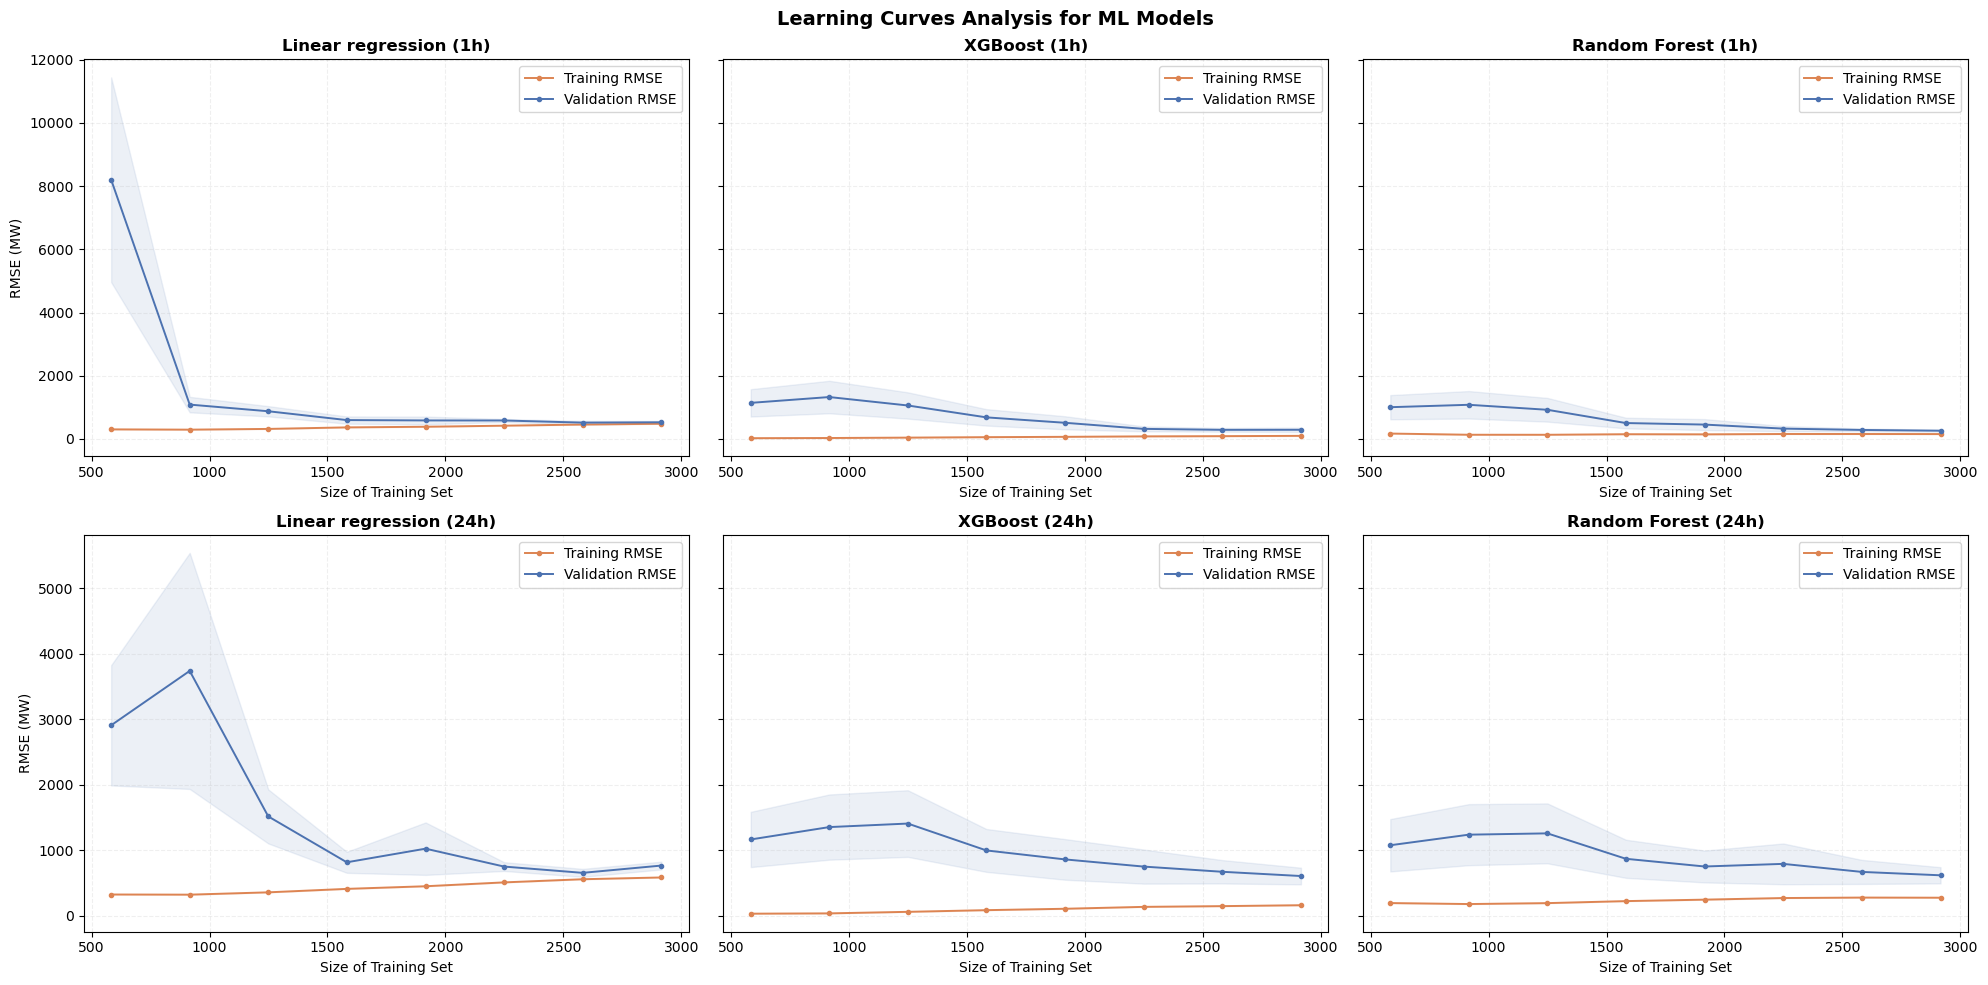

In [103]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey='row')

model_suite = [
    ('Linear regression', LinearRegression()),
    ('XGBoost', xgb.XGBRegressor(n_estimators=100,
                                 max_depth=6,
                                 learning_rate=0.05,
                                 subsample=0.8,
                                 colsample_bytree=0.8,
                                 random_state=SEED,
                                 n_jobs=-1)),
    ('Random Forest', RandomForestRegressor(n_estimators=100,
                                            max_depth=20,
                                            min_samples_leaf=5,
                                            random_state=SEED,
                                            n_jobs=-1))
]

evaluation_horizons = [('1h', TABULAR_FEATURES_1H), ('24h', TABULAR_FEATURES_24H)]
train_size_steps = np.linspace(0.2, 1.0, 8)

for col_idx, (model_label, model) in enumerate(model_suite):
    for row_idx, (horizon_label, features) in enumerate(evaluation_horizons):
        ax = axes[row_idx, col_idx]

        train_sizes, train_scores, val_scores = learning_curve(model,
                                                                df_train[features].values,
                                                                df_train[TARGET].values,
                                                                train_sizes=train_size_steps,
                                                                cv=TimeSeriesSplit(n_splits=CV_SPLITS),
                                                                scoring='neg_root_mean_squared_error',
                                                                n_jobs=-1,
                                                                random_state=SEED
        )

        mean_train_rmse = -train_scores.mean(axis=1)
        std_train_rmse = train_scores.std(axis=1)
        mean_val_rmse = -val_scores.mean(axis=1)
        std_val_rmse = val_scores.std(axis=1)

        ax.plot(train_sizes, mean_train_rmse, 'o-', color='#DD8452', label='Training RMSE', linewidth=1.4, markersize=3)
        ax.fill_between(train_sizes, mean_train_rmse - std_train_rmse, mean_train_rmse + std_train_rmse, color='#DD8452', alpha=0.1)

        ax.plot(train_sizes, mean_val_rmse, 'o-', color='#4C72B0', label='Validation RMSE', linewidth=1.4, markersize=3)
        ax.fill_between(train_sizes, mean_val_rmse - std_val_rmse, mean_val_rmse + std_val_rmse, color='#4C72B0', alpha=0.1)

        ax.set_xlabel('Size of Training Set')
        ax.set_title(f'{model_label} ({horizon_label})', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.2)
        ax.legend(fontsize=10)

        #Only label the leftmost y-axes (reduce visual clutter)
        if col_idx == 0:
            ax.set_ylabel('RMSE (MW)')

fig.suptitle('Learning Curves Analysis for ML Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Learning Curves Analysis for ML Models.png"), dpi=150, bbox_inches='tight')
plt.show()

# DNN

In [104]:
#Builder Function
def build_dnn(input_dim, layer_size, dropout_rate=0.2, learning_rate=0.001):
    """
    Construct a deep feedforward Dense Neural Network.

    Parameters:
        input_dim: Number of input features (14 for tabular)
        layer_sizes: List of neurons per hidden layer
        dropout_rate: Regularization parameter to mitigate overfitting
        learning_rate: Learning rate for Adam optimiser

    Returns:
        A compiled Sequential model (keras.Model)
    """
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for neurons in layer_size:
        model.add(Dense(neurons, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

    return model

dnn_config = {
    'DNN-2layer': [32, 16],
    'DNN-3layer': [64, 32, 16],
    'DNN-4layer': [128, 64, 32, 16]
}

print(f"Dropout rate: 0.2")
print(f"Optimiser: Adam(learning rate=0.001)")
print(f"\nConfigurations to test:")
for config_name, layers in dnn_config.items():
    total_desc = '->'.join([str(n) for n in layers])
    print(f" {config_name}: {len(layers)} hidden layers [{total_desc}] -> 1 output")

Dropout rate: 0.2
Optimiser: Adam(learning rate=0.001)

Configurations to test:
 DNN-2layer: 2 hidden layers [32->16] -> 1 output
 DNN-3layer: 3 hidden layers [64->32->16] -> 1 output
 DNN-4layer: 4 hidden layers [128->64->32->16] -> 1 output


In [105]:
#Train DNN
dnn_results = {}

for horizon_label, features in [('1h', TABULAR_FEATURES_1H), ('24h', TABULAR_FEATURES_24H)]:
    X_train_dnn = train_scaled[features].values
    y_train_dnn = train_scaled[TARGET].values
    X_val_dnn = val_scaled[features].values
    y_val_dnn = val_scaled[TARGET].values
    X_test_dnn = test_scaled[features].values
    y_test_dnn = test_scaled[TARGET].values

    for config_name, layer_size in dnn_config.items():
        model_tag = f"{config_name} ({horizon_label})"
        print(f"\nTraining {model_tag}..")

        model = build_dnn(input_dim=len(features),
                          layer_size=layer_size,
                          dropout_rate=0.2,
                          learning_rate=0.001)

        history = model.fit(X_train_dnn,
                            y_train_dnn,
                            validation_data=(X_val_dnn, y_val_dnn),
                            epochs=EPOCHS,
                            batch_size=BATCH_SIZE,
                            callbacks=[EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True, verbose=1),
                                       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)],
                            verbose=0)

        y_pred_dnn = model.predict(X_test_dnn, verbose=0).flatten()
        y_pred_dnn_aligned = y_pred_dnn[WINDOW_SIZE:]
        y_pred_dnn_scaled = y_pred_dnn_aligned

        #y_test_dnn is already scaled - trim to match
        y_true_dnn_aligned = y_test_dnn[WINDOW_SIZE:]

        result = evaluate_model(y_true_dnn_aligned, y_pred_dnn_scaled, target_scaler, model_tag)

        result['best_epoch'] = np.argmin(history.history['val_loss']) + 1
        result['total_epochs'] = len(history.history['loss'])
        result['history'] = history

        dnn_results[model_tag] = result
        print(f" Best epoch: {result['best_epoch']},"
              f" Stopped at epoch: {result['total_epochs']}")
                                       


Training DNN-2layer (1h)..

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 34: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 50.
DNN-2layer (1h): RMSE=270.33 MW, MAE=154.90 MW, nRMSE=16.87%, R2=0.9881
 Best epoch: 50, Stopped at epoch: 50

Training DNN-3layer (1h)..

Epoch 26: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 46: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 36.
DNN-3layer (1h): RMSE=264.66 MW, MAE=157.78 MW, nRMSE=16.51%, R2=0.9886
 Best epoch: 36, Stopped at epoch: 46

Training DNN-4layer (1h)..

Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoc

Comparison of DNN Configuration
           Model  RMSE (MW)  MAE (MW)  nRMSE (%)     R2  Best Epoch  Total Epochs
 DNN-2layer (1h)   270.3341  154.9013    16.8669 0.9881          50            50
 DNN-3layer (1h)   264.6560  157.7793    16.5126 0.9886          36            46
 DNN-4layer (1h)   282.1614  174.0842    17.6049 0.9870          20            30
DNN-2layer (24h)   769.8010  419.8884    48.0301 0.9035           6            16
DNN-3layer (24h)   762.7082  401.8272    47.5875 0.9053          14            24
DNN-4layer (24h)   765.2674  404.4536    47.7472 0.9046          20            30

Best DNN Configuration for 1h: DNN-3layer (1h) (RMSE=264.66 MW, R2=0.9886)

Best DNN Configuration for 24h: DNN-3layer (24h) (RMSE=762.71 MW, R2=0.9053)


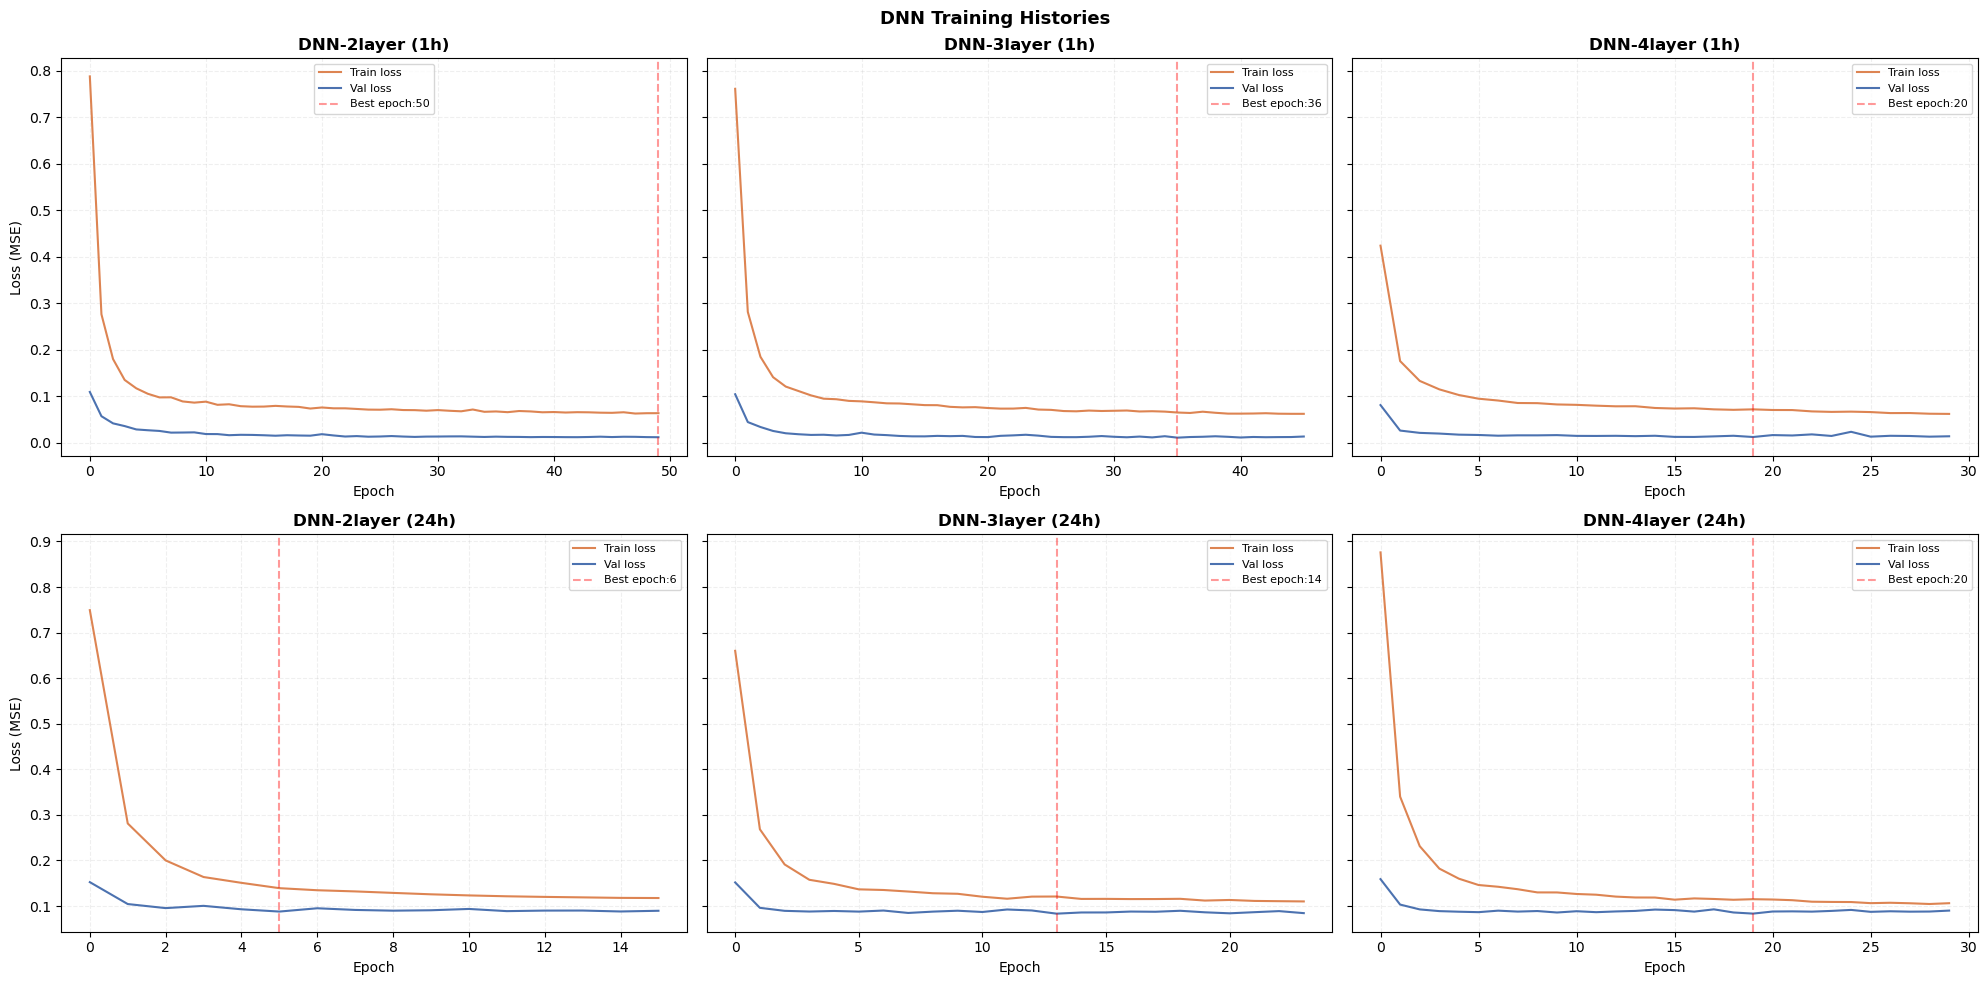

In [107]:
#DNN comparison and the best configuration
dnn_summary = []
for model_tag, result in dnn_results.items():
    dnn_summary.append({'Model': result['name'],
                        'RMSE (MW)': result['rmse'],
                        'MAE (MW)': result['mae'],
                        'nRMSE (%)': result['nrmse'],
                        'R2': result['r2'],
                        'Best Epoch': np.argmin(result['history'].history['val_loss']) + 1,
                        'Total Epochs': result['total_epochs']})

df_dnn = pd.DataFrame(dnn_summary)
print("Comparison of DNN Configuration")
print("=" * 80)
print(df_dnn.round(4).to_string(index=False))

#Best per horizon
for horizon in ['1h', '24h']:
    horizon_results = df_dnn[df_dnn['Model'].str.contains(horizon)]
    best = horizon_results.loc[horizon_results['RMSE (MW)'].idxmin()]
    print(f"\nBest DNN Configuration for {horizon}: {best['Model']} (RMSE={best['RMSE (MW)']:.2f} MW, R2={best['R2']:.4f})")

#Plots for training history
fig, axes = plt.subplots(2, 3, figsize =(20, 10), sharey='row')

for idx, (model_tag, result) in enumerate(dnn_results.items()):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    history = result['history']
    ax.plot(history.history['loss'], label='Train loss', linewidth=1.5, color='#DD8452')
    ax.plot(history.history['val_loss'], label='Val loss', linewidth=1.5, color='#4C72B0')

    best_epoch = np.argmin(history.history['val_loss'])
    ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.4, label=f'Best epoch:{best_epoch + 1}')

    ax.set_xlabel('Epoch')
    ax.set_title(model_tag, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.2)

    if col == 0:
        ax.set_ylabel('Loss (MSE)')

fig.suptitle('DNN Training Histories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "DNN Training Histories.png"), dpi=150, bbox_inches='tight')
plt.show()

# Recurrent Models (LSTM, BiLSTM, GRU, Stacked LSTM)

### Models Architecture 

In [16]:
DROPOUT_RATE = 0.2
HIDDEN_UNITS = 64
INPUT_SHAPE = (WINDOW_SIZE, len(RECURRENT_FEATURES))

def build_lstm(input_shape=INPUT_SHAPE, drop_r=DROPOUT_RATE):
    """Vanilla LSTM: Single recurrent layer and a Dense output projection."""
    model = Sequential([
        LSTM(HIDDEN_UNITS, input_shape=input_shape),
        Dropout(drop_r),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return model

def build_bilstm(input_shape=INPUT_SHAPE, drop_r=DROPOUT_RATE):
    """BiLSTM: Processes window forwards and backwards.
    Functional model forcing training=True on Dropout nodes. Enforces active dropout during both training and validation.
    Enables Monte Carlo sampling at prediciton time.

    The consequence is every call to .predict() is stochastic. A single pass is standard practice for point evaluation.
    Run 100 passes for uncertainty quantification."""

    inp = Input(shape=input_shape)
    x = Bidirectional(LSTM(HIDDEN_UNITS))(inp)
    x = Dropout(drop_r)(x, training=True)
    x = Dense(32, activation='relu')(x)
    x = Dropout(drop_r)(x, training=True)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return model

def build_gru(input_shape=INPUT_SHAPE, drop_r=DROPOUT_RATE):
    """GRU: Only reset and update gates."""
    model = Sequential([
        GRU(HIDDEN_UNITS, input_shape=input_shape),
        Dropout(drop_r),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return model

def build_stacked_lstm(input_shape=INPUT_SHAPE, drop_r=DROPOUT_RATE):
    """Stacked LSTM: Multi-layer LSTM (two layers) for hierarchical features.
    The first layer returns full sequence for second layer to process."""

    model = Sequential([
        LSTM(HIDDEN_UNITS, input_shape=input_shape, return_sequences=True),
        Dropout(drop_r),
        LSTM(32),
        Dropout(drop_r),
        Dense(32, activation='relu'),
        Dense(1)
    ])   
    model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0), loss='mse')
    return model

recurrent_builds = {
    'LSTM': build_lstm,
    'BiLSTM': build_bilstm,
    'GRU': build_gru,
    'Stacked LSTM': build_stacked_lstm
}

print(f"Input shape: {INPUT_SHAPE}")
print(f"Recurrent architectures define: {list(recurrent_builds.keys())}")
print(f"Dropout rate: {DROPOUT_RATE}")
print(f"Hidden units: {HIDDEN_UNITS}")
print(f"Gradient clipping: clipnorm=1.0 for all models")
print(f"BiLSTM: Dropout active during inference (training=True) for Monte Carlo Dropout")

Input shape: (24, 14)
Recurrent architectures define: ['LSTM', 'BiLSTM', 'GRU', 'Stacked LSTM']
Dropout rate: 0.2
Hidden units: 64
Gradient clipping: clipnorm=1.0 for all models
BiLSTM: Dropout active during inference (training=True) for Monte Carlo Dropout


### Models Training Function

In [17]:
def train_recurrent(model, X_train, y_train, X_val, y_val, model_tag, epochs=EPOCHS, batch_size=BATCH_SIZE):
    """
    Recurrent model trained with early stopping and learning rate reduction.
    Returns a Keras History dictionary mapping for post-hoc analysis.
    """

    callbacks = [EarlyStopping(monitor='val_loss',
                               patience=PATIENCE,
                               restore_best_weights=True,
                               verbose=1),
                ReduceLROnPlateau(monitor='val_loss',
                                  factor=0.5,
                                  patience=5,
                                  min_lr=1e-6,
                                  verbose=1)]

    print(f"\n{'=' * 70}")
    print(f"Training {model_tag}...")
    print(f"Parameters: {model.count_params():,}")
    print(f"{'=' * 70}")

    start = time.time()
    history = model.fit(X_train,
                        y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs,
                        batch_size=batch_size,
                        callbacks=callbacks,
                        verbose=1)
    elapsed = time.time() - start

    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])

    print(f"\n{model_tag}: {elapsed:.1f}s, "
          f"Best epoch: {best_epoch}/{len(history.history['loss'])}, "
          f"Best val_loss: {best_val_loss:.6f}")
    
    return history


### Models Training

In [114]:
#Train all 4 architectures with the 2 horizons - 8 models total
horizon_data = {'1h': (X_train_1h, y_train_1h, X_val_1h, y_val_1h),
                '24h': (X_train_24h, y_train_24h, X_val_24h, y_val_24h)}

recurrent_models = {}
recurrent_histories = {}

total_start = time.time()

for arch_name, model_builder_fn in recurrent_builds.items():
    for horizon, (X_train, y_train, X_val, y_val) in horizon_data.items():
        model_tag = f"{arch_name} ({horizon})"
        model_key = f"{arch_name}_{horizon}"

        model = model_builder_fn()
        history = train_recurrent(model, X_train, y_train, X_val, y_val, model_tag)

        recurrent_models[model_key] = model
        recurrent_histories[model_key] = history

total_elapsed = time.time() - total_start
print(f"\n{'=' * 90}")
print(f"Time for all 8 recurrent models trained - {total_elapsed/60:.1f} minutes")
print(f"Models stored: {list(recurrent_models.keys())}")
print(f"{'=' * 90}")


Training LSTM (1h)...
Parameters: 22,337
Epoch 1/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1285 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 2/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0321 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 3/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0227 - val_loss: 0.0148 - learning_rate: 0.0010
Epoch 4/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0189 - val_loss: 0.0120 - learning_rate: 0.0010
Epoch 5/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0165 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 6/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0148 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 7/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0145 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 8/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0130 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 9/50
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0127 - 

### Models Summary of Key Architectures

In [115]:
#BiLSTM model summary
print("BiLSTM Architecture:")
print('=' * 70)
recurrent_models['BiLSTM_1h'].summary()

#GRU model summary
print(f"\n\nGRU Architecture:")
print("=" * 90)
recurrent_models['GRU_1h'].summary()

BiLSTM Architecture:


Model: "functional_138"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_30 (InputLayer)     │ (None, 24, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,829 (522.77 KB)

 Trainable params: 44,609 (174.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 64)             │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,421 (204.77 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,948 (136.52 KB)

In [116]:
#Comparison of trainable parameter count
lstm_params = recurrent_models['LSTM_1h'].count_params()

print("Trainable parameter count by architecture:")
print(f"{'Architecture':<20} {'Parameters':>12} {'vs LSTM':>10}")
print("-" * 50)

for arch_name in recurrent_builds.keys():
    model_key = f"{arch_name}_1h"
    params = recurrent_models[model_key].count_params()
    ratio = params / lstm_params
    print(f"{arch_name:<20} {params:>12,} {ratio:>9.2f}x")

print(f"\nNote: The parameter counts are identical for 1h and 24h horizons")
print(f"(Only target changes, the rest are same - same input, architecture)")

Trainable parameter count by architecture:
Architecture           Parameters    vs LSTM
--------------------------------------------------
LSTM                       22,337      1.00x
BiLSTM                     44,609      2.00x
GRU                        17,473      0.78x
Stacked LSTM               33,729      1.51x

Note: The parameter counts are identical for 1h and 24h horizons
(Only target changes, the rest are same - same input, architecture)


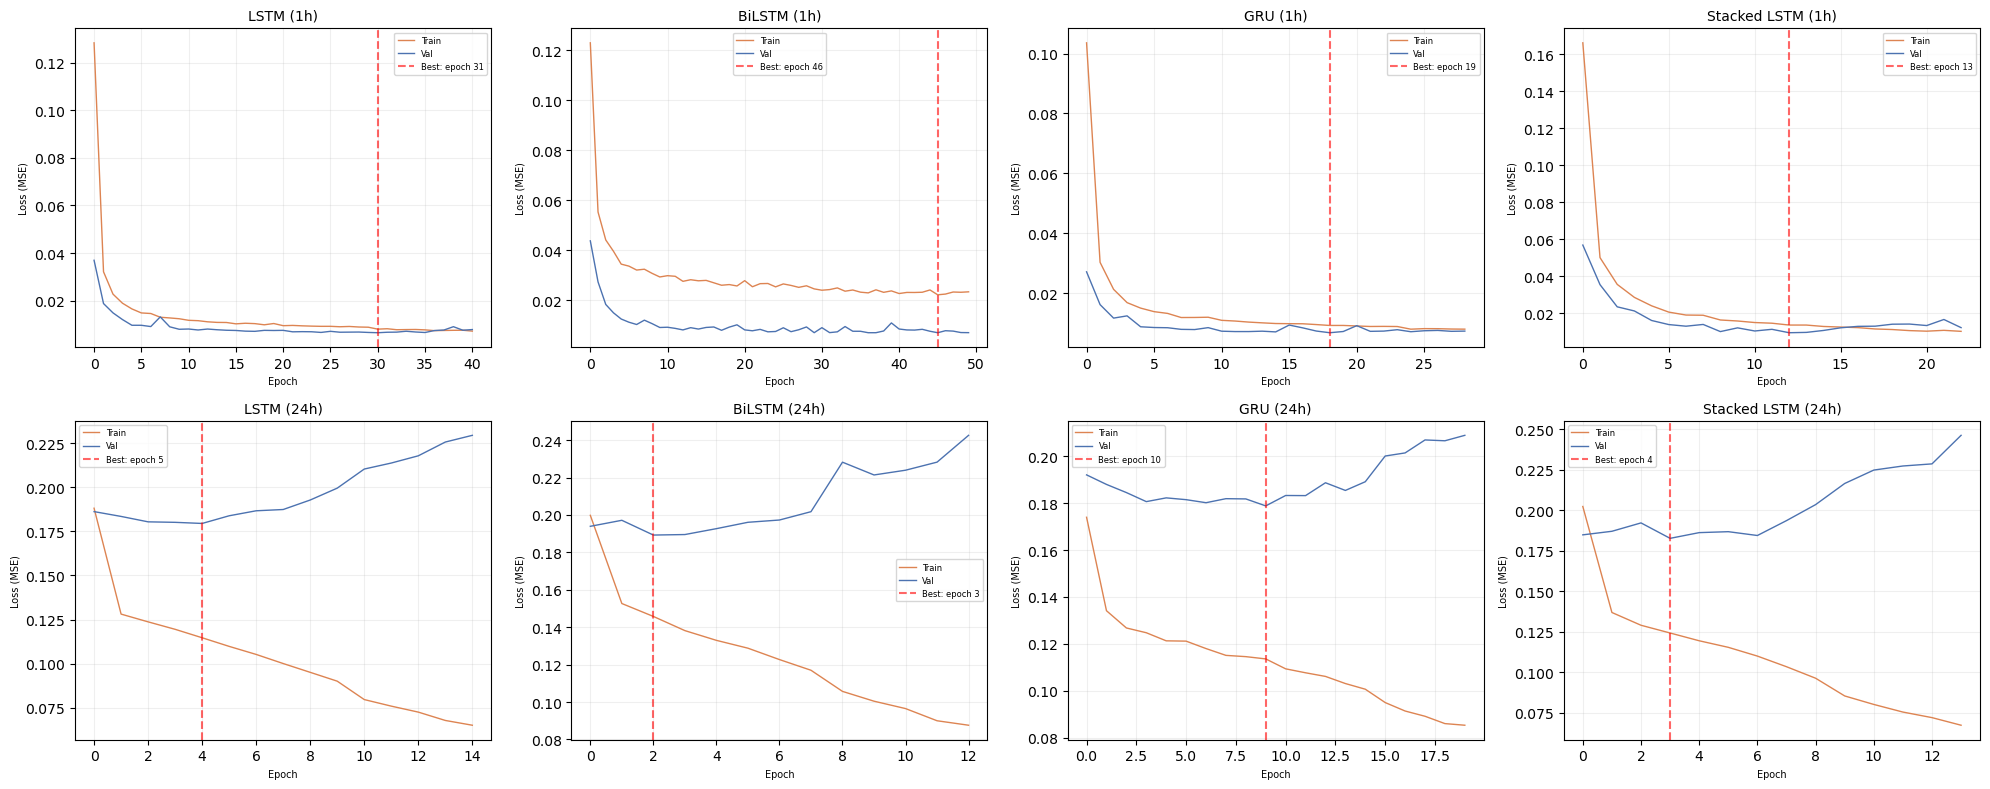

In [117]:
#Plots of training histories - overfitting check
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

plot_order = [('LSTM_1h', 'LSTM (1h)'),
              ('BiLSTM_1h', 'BiLSTM (1h)'),
              ('GRU_1h', 'GRU (1h)'),
              ('Stacked LSTM_1h', 'Stacked LSTM (1h)'),
              ('LSTM_24h', 'LSTM (24h)'),
              ('BiLSTM_24h', 'BiLSTM (24h)'),
              ('GRU_24h', 'GRU (24h)'),
              ('Stacked LSTM_24h', 'Stacked LSTM (24h)')]

for ax, (model_key, title) in zip(axes.flatten(), plot_order):
    history = recurrent_histories[model_key]
    best_epoch = np.argmin(history.history['val_loss']) + 1

    ax.plot(history.history['loss'], label='Train', linewidth=1, color='#DD8452')
    ax.plot(history.history['val_loss'], label='Val', linewidth=1, color='#4C72B0')
    ax.axvline(x=best_epoch - 1, color='red', linestyle='--', alpha=0.6, label=f'Best: epoch {best_epoch}')
    ax.set_xlabel('Epoch', fontsize=7)
    ax.set_ylabel('Loss (MSE)', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Recurrent Models Training Histories.png"), dpi=150)
plt.show()

In [120]:
#Summary of training outcomes for all models
print("Training outcomes summary:")
print(f"{'Model':<25} {'Epochs Trained':>15} {'Best Epoch':>12} {'Best Val Loss':>15}")

for model_key in recurrent_histories:
    history = recurrent_histories[model_key]
    epochs_trained = len(history.history['loss'])
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = min(history.history['val_loss'])

    arch, horizon = model_key.rsplit('_', 1)
    display = f"{arch} ({horizon})"

    print(f"{display:<25} {epochs_trained:>15} {best_epoch:>12} {best_val_loss:>15.6f}")

#Idenitfy any models that hit max epochs
max_epoch_models = [k for k, h in recurrent_histories.items()
                    if len(h.history['loss']) == EPOCHS]

if max_epoch_models:
    print(f"\nNote: {max_epoch_models} trained all {EPOCHS} epochs without early stopping.")
    print("Consider increasing epochs or investigate convergence.")
else:
    print(f"\nAll models triggered early stopping before {EPOCHS} epochs.")

Training outcomes summary:
Model                      Epochs Trained   Best Epoch   Best Val Loss
LSTM (1h)                              41           31        0.006458
LSTM (24h)                             15            5        0.179520
BiLSTM (1h)                            50           46        0.007023
BiLSTM (24h)                           13            3        0.189256
GRU (1h)                               29           19        0.006827
GRU (24h)                              20           10        0.178884
Stacked LSTM (1h)                      23           13        0.009520
Stacked LSTM (24h)                     14            4        0.182725

Note: ['BiLSTM_1h'] trained all 50 epochs without early stopping.
Consider increasing epochs or investigate convergence.


### Models Predictions

In [19]:
#Recurrent predictions generated on test set
recurrent_results = {}
for arch_name in recurrent_builds.keys():
    key_1h = f"{arch_name}_1h"
    y_pred_1h = recurrent_models[key_1h].predict(X_test_1h, verbose=0).flatten()
    recurrent_results[key_1h] = evaluate_model(y_test_1h, y_pred_1h, target_scaler, f"{arch_name} (1h)")

    key_24h = f"{arch_name}_24h"
    y_pred_24h = recurrent_models[key_24h].predict(X_test_24h, verbose=0).flatten()
    recurrent_results[key_24h] = evaluate_model(y_test_24h, y_pred_24h, target_scaler, f"{arch_name} (24h)")

print(f"\nRecurrent models results stored: {list(recurrent_results.keys())}")

LSTM (1h): RMSE=197.51 MW, MAE=111.17 MW, nRMSE=12.32%, R2=0.9936
LSTM (24h): RMSE=988.59 MW, MAE=528.57 MW, nRMSE=61.53%, R2=0.8411
BiLSTM (1h): RMSE=206.94 MW, MAE=120.89 MW, nRMSE=12.91%, R2=0.9930
BiLSTM (24h): RMSE=1020.02 MW, MAE=569.65 MW, nRMSE=63.48%, R2=0.8308
GRU (1h): RMSE=202.87 MW, MAE=108.86 MW, nRMSE=12.66%, R2=0.9933
GRU (24h): RMSE=976.71 MW, MAE=523.10 MW, nRMSE=60.79%, R2=0.8449
Stacked LSTM (1h): RMSE=246.37 MW, MAE=160.29 MW, nRMSE=15.37%, R2=0.9901
Stacked LSTM (24h): RMSE=992.92 MW, MAE=533.53 MW, nRMSE=61.80%, R2=0.8397

Recurrent models results stored: ['LSTM_1h', 'LSTM_24h', 'BiLSTM_1h', 'BiLSTM_24h', 'GRU_1h', 'GRU_24h', 'Stacked LSTM_1h', 'Stacked LSTM_24h']


In [122]:
#All models results comparison table
all_results = []

#Results for Naive baselines
for result, tier in [(persistence_1h_results, 'Naive Baseline'),
                     (persistence_24h_results, 'Naive Baseline'),
                     (mean_1h_results, 'Naive Baseline'),
                     (mean_24h_results, 'Naive Baseline')]:
    all_results.append({'name': result['name'], 
                        'tier': tier,
                        'rmse': result['rmse'],
                        'mae': result['mae'],
                        'nrmse': result['nrmse'],
                        'r2': result['r2']})

#Results for Linear regression
for result, tier in [(lin_1h_results, 'Statistical Baseline'),
                     (lin_24h_results, 'Statistical Baseline')]:
    all_results.append({'name': result['name'],
                        'tier': tier,
                        'rmse': result['rmse'],
                        'mae': result['mae'],
                        'nrmse': result['nrmse'],
                        'r2': result['r2']})

#Results for Classical ML
for result, tier in [(xgb_1h_results, 'Classical ML'),
                     (xgb_24h_results, 'Classical ML'),
                     (rf_1h_results, 'Classical ML'),
                     (rf_24h_results, 'Classical ML')]:
    all_results.append({'name': result['name'],
                        'tier': tier,
                        'rmse': result['rmse'],
                        'mae': result['mae'],
                        'nrmse': result['nrmse'],
                        'r2': result['r2']})

#Results for DNN
for model_tag, result in dnn_results.items():
    all_results.append({'name': result['name'],
                        'tier': 'DNN',
                        'rmse': result['rmse'],
                        'mae': result['mae'],
                        'nrmse': result['nrmse'],
                        'r2': result['r2']})

#Results for Recurrent DL
for model_key, result in recurrent_results.items():
    all_results.append({'name': result['name'],
                        'tier': 'Recurrent DL',
                        'rmse': result['rmse'],
                        'mae': result['mae'],
                        'nrmse': result['nrmse'],
                        'r2': result['r2']})

df_results = pd.DataFrame(all_results)
df_results['horizon'] = df_results['name'].apply(lambda x: '1h' if '(1h)' in x else '24h')
df_results = df_results.sort_values(['horizon', 'rmse']).reset_index(drop=True)

print("=" * 95)
print("All model comparison")
print("=" * 95)

for horizon_label in ['1h', '24h']:
    subset = df_results[df_results['horizon'] == horizon_label]
    print(f"\n---{horizon_label.upper()} Forecasting Horizon")
    print(f"{'Model':<30} {'Tier':<20} {'RMSE':>10} {'MAE':>10} {'nRMSE':>10} {'R2':>8}")
    print("-" * 95)
    for _, row in subset.iterrows():
        print(f"{row['name']:<30} {row['tier']:<20} "
              f"{row['rmse']:>10.2f} {row['mae']:>10.2f} "
              f"{row['nrmse']:>10.2f} {row['r2']:>8.4f}")
        
print("\n" + "=" * 95)
for horizon_label in ['1h', '24h']:
    subset = df_results[df_results['horizon'] == horizon_label]
    best_model = subset.loc[subset['rmse'].idxmin()]
    print(f"\nBest {horizon_label}: {best_model['name']} (RMSE={best_model['rmse']:.2f} MW, R2={best_model['r2']:.4f})")
print("=" * 95)

All model comparison

---1H Forecasting Horizon
Model                          Tier                       RMSE        MAE      nRMSE       R2
-----------------------------------------------------------------------------------------------
LSTM (1h)                      Recurrent DL             197.51     111.17      12.32   0.9936
GRU (1h)                       Recurrent DL             202.87     108.86      12.66   0.9933
BiLSTM (1h)                    Recurrent DL             206.94     120.89      12.91   0.9930
Stacked LSTM (1h)              Recurrent DL             246.37     160.29      15.37   0.9901
DNN-3layer (1h)                DNN                      264.66     157.78      16.51   0.9886
DNN-2layer (1h)                DNN                      270.33     154.90      16.87   0.9881
XGBoost (1h)                   Classical ML             279.19     138.31      17.42   0.9873
Random Forest (1h)             Classical ML             280.60     138.30      17.51   0.9872
DNN-4layer

In [123]:
#Compare train, val, and test RMSE for all DL models
std_mw = target_scaler.scale_[0]
overfit_rows = []

#DNN models
for model_tag, result in dnn_results.items():
    history = result['history']
    best_idx = result['best_epoch'] - 1
    train_rmse = np.sqrt(history.history['loss'][best_idx]) * std_mw
    val_rmse = np.sqrt(history.history['val_loss'][best_idx]) * std_mw
    test_rmse = result['rmse']
    ratio = val_rmse /  train_rmse if train_rmse > 0 else np.nan

    overfit_rows.append({'model': model_tag,
                         'tier': 'DNN',
                         'train_rmse': train_rmse,
                         'val_rmse': val_rmse,
                         'test_rmse': test_rmse, 
                         'val_train_ratio': ratio,
                         'best_epoch': result['best_epoch']})

#Recurrent models
for model_key, hist in recurrent_histories.items():
    arch, horizon = model_key.rsplit('_', 1)
    model_tag = f"{arch} ({horizon})"
    best_idx = np.argmin(hist.history['val_loss'])
    train_rmse = np.sqrt(hist.history['loss'][best_idx]) * std_mw
    val_rmse = np.sqrt(hist.history['val_loss'][best_idx]) * std_mw
    test_rmse = recurrent_results[model_key]['rmse']
    ratio = val_rmse / train_rmse if train_rmse > 0 else np.nan

    overfit_rows.append({'model': model_tag,
                         'tier': 'Recurrent DL',
                         'train_rmse': train_rmse,
                         'val_rmse': val_rmse,
                         'test_rmse': test_rmse,
                         'val_train_ratio': ratio,
                         'best_epoch': best_idx + 1})

df_overfit = pd.DataFrame(overfit_rows)
df_overfit['horizon'] = df_overfit['model'].apply(lambda x: '1h' if '(1h)' in x else '24h')
df_overfit = df_overfit.sort_values(['horizon', 'test_rmse']).reset_index(drop=True)

print("Overfitting Analysis: Train / Val / Test RMSE (MW)")
print("=" * 100)
print(f"{'Model':<25} {'Train RMSE':>12} {'Val RMSE':>12} {'Test RMSE':>12} "
      f"{'Val/Train':>10} {'Best Epoch':>12}")
print("=" * 100)

for _, row in df_overfit.iterrows():
    print(f"{row['model']:<25} {row['train_rmse']:>12.2f} {row['val_rmse']:>12.2f} "
          f"{row['test_rmse']:>12.2f} {row['val_train_ratio']:>10.2f} "
          f"{row['best_epoch']:>12}")
    
print(f"\nNote: Val/Train ratio approximately 1.0 is good generalisation while >1.5 is moderate overfitting")
print(f"Note: Train and val RMSE for BiLSTM are inflated by training=True dropout")
print(f"Target scaler std: {std_mw:.2f} MW (used for MSE-to-RMSE conversion)")

Overfitting Analysis: Train / Val / Test RMSE (MW)
Model                       Train RMSE     Val RMSE    Test RMSE  Val/Train   Best Epoch
LSTM (1h)                       195.08       175.63       197.51       0.90           31
GRU (1h)                        210.23       180.57       202.87       0.86           19
BiLSTM (1h)                     325.66       183.15       206.94       0.56           46
Stacked LSTM (1h)               255.47       213.24       246.37       0.83           13
DNN-3layer (1h)                 559.30       233.83       264.66       0.42           36
DNN-2layer (1h)                 553.17       243.08       270.33       0.44           50
DNN-4layer (1h)                 587.73       247.79       282.16       0.42           20
DNN-3layer (24h)                759.77       630.56       762.71       0.83           14
DNN-4layer (24h)                741.08       631.04       765.27       0.85           20
DNN-2layer (24h)                815.34       647.72       7

In [124]:
#Stratified regime evaluation - RQ3
#Collect key models for regime analysis
regime_models_1h = {'Smart Persistence': (persistence_1h_results, persistence_idx),
                    'XGBoost': (xgb_1h_results, persistence_idx)}

#Extract optimal 1h DNN configuration
best_dnn_1h_key = min([k for k in dnn_results if '(1h)' in k],
                      key=lambda k: dnn_results[k]['rmse'])
regime_models_1h[best_dnn_1h_key] = (dnn_results[best_dnn_1h_key], persistence_idx)

#Add all recurrent 1h
for model_key, result in recurrent_results.items():
    if '_1h' in model_key:
        arch = model_key.replace('_1h', '')
        regime_models_1h[f"{arch}"] = (result, idx_test_1h)

print("=" * 90)
print("Stratified evaluation by regime - 1h horizon (RQ3)")
print("=" * 90)

regime_analysis_1h = {}
for model_label, (result, timestamps) in regime_models_1h.items():
    print(f"\n{model_label}:")
    regime_result = evaluate_by_regime(result['y_true'],
                                       result['y_pred'],
                                       timestamps,
                                       df_test,
                                       model_label)
    regime_analysis_1h[model_label] = regime_result

#Evaluate 24h horizon regimes
print(f"\n{'=' * 90}")
print("Stratified evaluation by regime - 24h horizon (RQ3)")
print("=" * 90)

regime_models_24h ={'Smart Persistence': (persistence_24h_results, persistence_idx),
                    'XGBoost': (xgb_24h_results, persistence_idx)}

best_dnn_24h_key = min([k for k in dnn_results if ('24h') in k],
                       key=lambda k: dnn_results[k]['rmse'])
regime_models_24h[best_dnn_24h_key] = (dnn_results[best_dnn_24h_key], persistence_idx)

for model_key, result in recurrent_results.items():
    if'_24h' in model_key:
        arch = model_key.replace('_24h', '')
        regime_models_24h[f"{arch}"] = (result, idx_test_24h)

regime_analysis_24h = {}
for model_label, (result, timestamps) in regime_models_24h.items():
    print(f"\n{model_label}:")
    regime_result = evaluate_by_regime(result['y_true'],
                                       result['y_pred'],
                                       timestamps,
                                       df_test,
                                       model_label)
    regime_analysis_24h[model_label] = regime_result
   

Stratified evaluation by regime - 1h horizon (RQ3)

Smart Persistence:
 Low (<25%): RMSE=645.49, MAE=355.67, R2=0.6581, n=2475
 Moderate (25-40%): RMSE=851.74, MAE=536.44, R2=0.8511, n=2386
 High (> 40%): RMSE=765.77, MAE=465.49, R2=0.9343, n=3899

XGBoost:
 Low (<25%): RMSE=153.22, MAE=68.22, R2=0.9807, n=2475
 Moderate (25-40%): RMSE=247.53, MAE=133.53, R2=0.9874, n=2386
 High (> 40%): RMSE=350.32, MAE=185.73, R2=0.9862, n=3899

DNN-3layer (1h):
 Low (<25%): RMSE=161.43, MAE=99.01, R2=0.9786, n=2475
 Moderate (25-40%): RMSE=254.86, MAE=158.74, R2=0.9867, n=2386
 High (> 40%): RMSE=317.93, MAE=194.50, R2=0.9887, n=3899

LSTM:
 Low (<25%): RMSE=124.50, MAE=68.08, R2=0.9873, n=2475
 Moderate (25-40%): RMSE=190.56, MAE=111.21, R2=0.9925, n=2386
 High (> 40%): RMSE=235.77, MAE=138.49, R2=0.9938, n=3899

BiLSTM:
 Low (<25%): RMSE=127.35, MAE=75.31, R2=0.9867, n=2475
 Moderate (25-40%): RMSE=197.71, MAE=119.26, R2=0.9920, n=2386
 High (> 40%): RMSE=248.99, MAE=150.82, R2=0.9931, n=3899

GRU

Best recurrent model for 1h: LSTM (1h) (RMSE=197.51 MW)


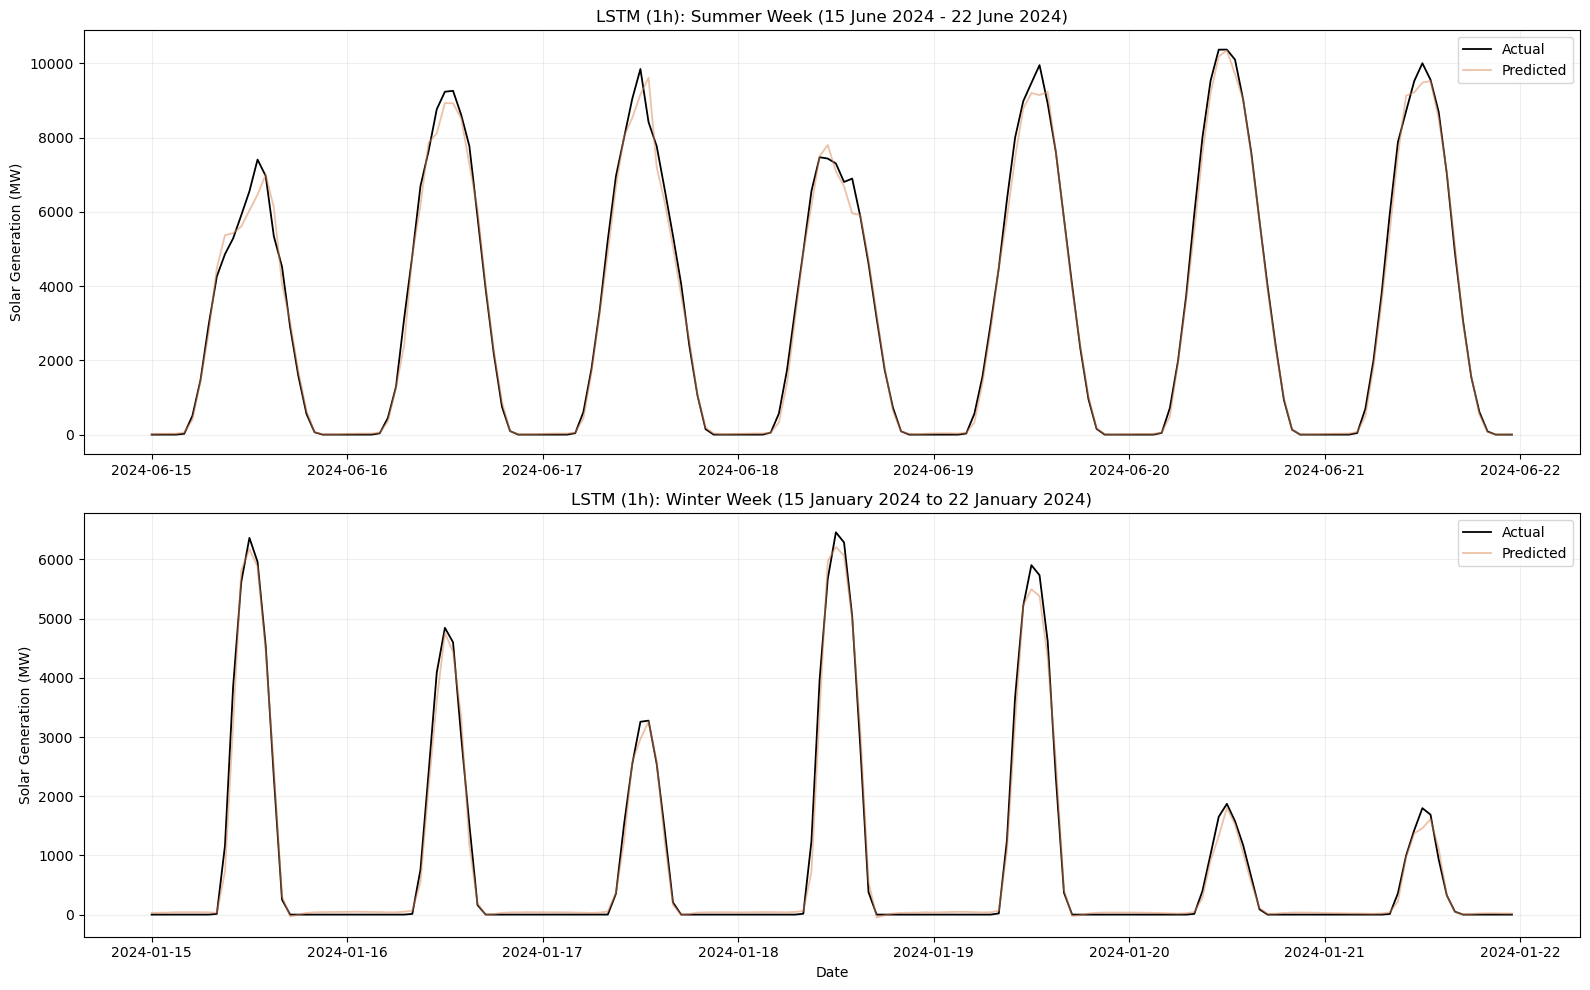

In [125]:
#Time-series comparison for best recurrent model (summer and winter weeks)
best_recurrent_1h_key = min([k for k in recurrent_results if '_1h' in k],
                            key=lambda k: recurrent_results[k]['rmse'])
best_1h = recurrent_results[best_recurrent_1h_key]
best_1h_name = best_1h['name']

print(f"Best recurrent model for 1h: {best_1h_name} (RMSE={best_1h['rmse']:.2f} MW)")

fig,axes = plt.subplots(2, 1, figsize=(16,10), sharex=False)

#Summer week - high generation
summer_mask = (idx_test_1h >= '2024-06-15') & (idx_test_1h < '2024-06-22')
axes[0].plot(idx_test_1h[summer_mask], best_1h['y_true'][summer_mask], label='Actual', color='black', linewidth=1.3)
axes[0].plot(idx_test_1h[summer_mask], best_1h['y_pred'][summer_mask], label='Predicted', color='#DD8452', linewidth=1.3, alpha=0.5)
axes[0].set_ylabel('Solar Generation (MW)')
axes[0].set_title(f'{best_1h_name}: Summer Week (15 June 2024 - 22 June 2024)')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

#Winter week - low generation
winter_mask = (idx_test_1h >= '2024-01-15') & (idx_test_1h < '2024-01-22')
axes[1].plot(idx_test_1h[winter_mask], best_1h['y_true'][winter_mask], label='Actual', color='black', linewidth=1.3)
axes[1].plot(idx_test_1h[winter_mask], best_1h['y_pred'][winter_mask], label='Predicted', color='#DD8452', linewidth=1.3, alpha=0.5)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Solar Generation (MW)')
axes[1].set_title(f'{best_1h_name}: Winter Week (15 January 2024 to 22 January 2024)')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Actual vs Predicted for Summer and Winter Weeks.png"), dpi=150)
plt.show()

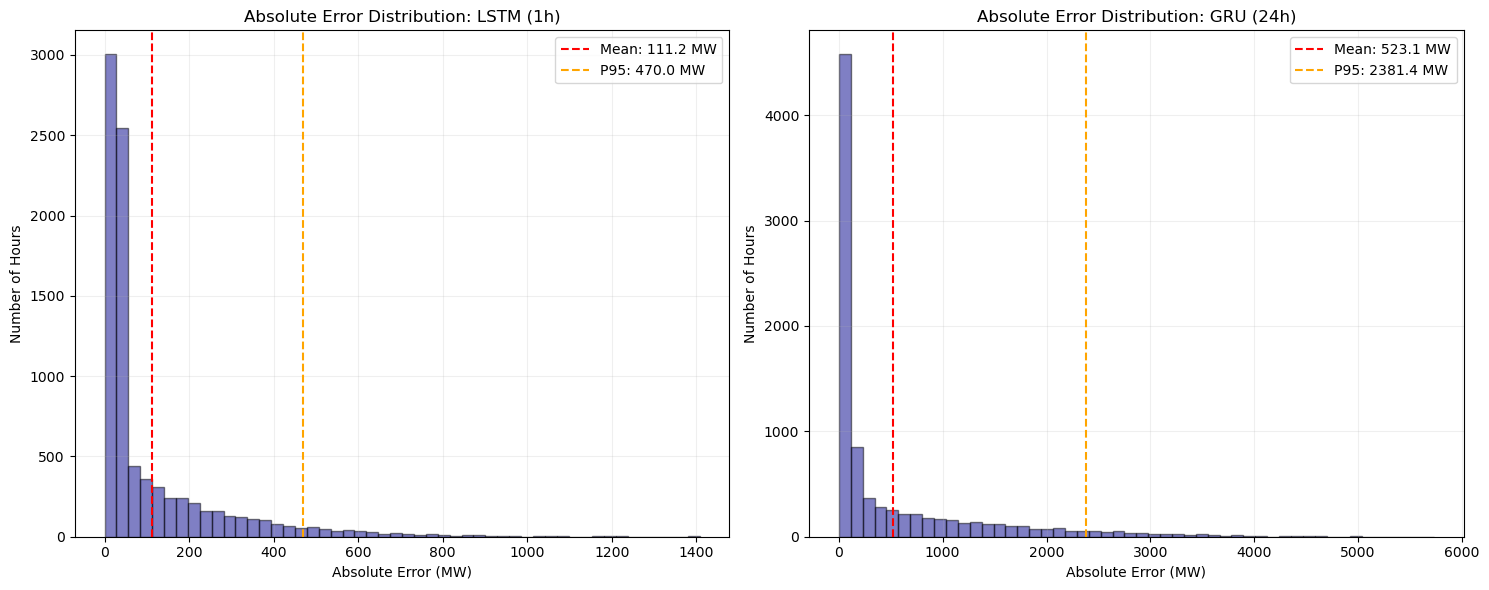

In [126]:
#Error distribution histogram - absolute errors for best recurrent model
best_recurrent_24h_key = min([k for k in recurrent_results if '_24h' in k],
                             key=lambda k: recurrent_results[k]['rmse'])
best_24h = recurrent_results[best_recurrent_24h_key]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, result, horizon in [(axes[0], best_1h, '1h'), (axes[1], best_24h, '24h')]:
    errors = np.abs(result['y_true'] - result['y_pred'])
    ax.hist(errors, bins=50, edgecolor='black', color='darkblue', alpha=0.5)
    ax.axvline(x=errors.mean(), color='red', linestyle='--', label=f'Mean: {errors.mean():.1f} MW')
    ax.axvline(x=np.percentile(errors, 95), color='orange', linestyle='--', label=f'P95: {np.percentile(errors, 95):.1f} MW')
    ax.set_xlabel('Absolute Error (MW)')
    ax.set_ylabel('Number of Hours')
    ax.set_title(f"Absolute Error Distribution: {result['name']}")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Absolute Error Distribution for Best Recurrent Model.png"), dpi=150)
plt.show()

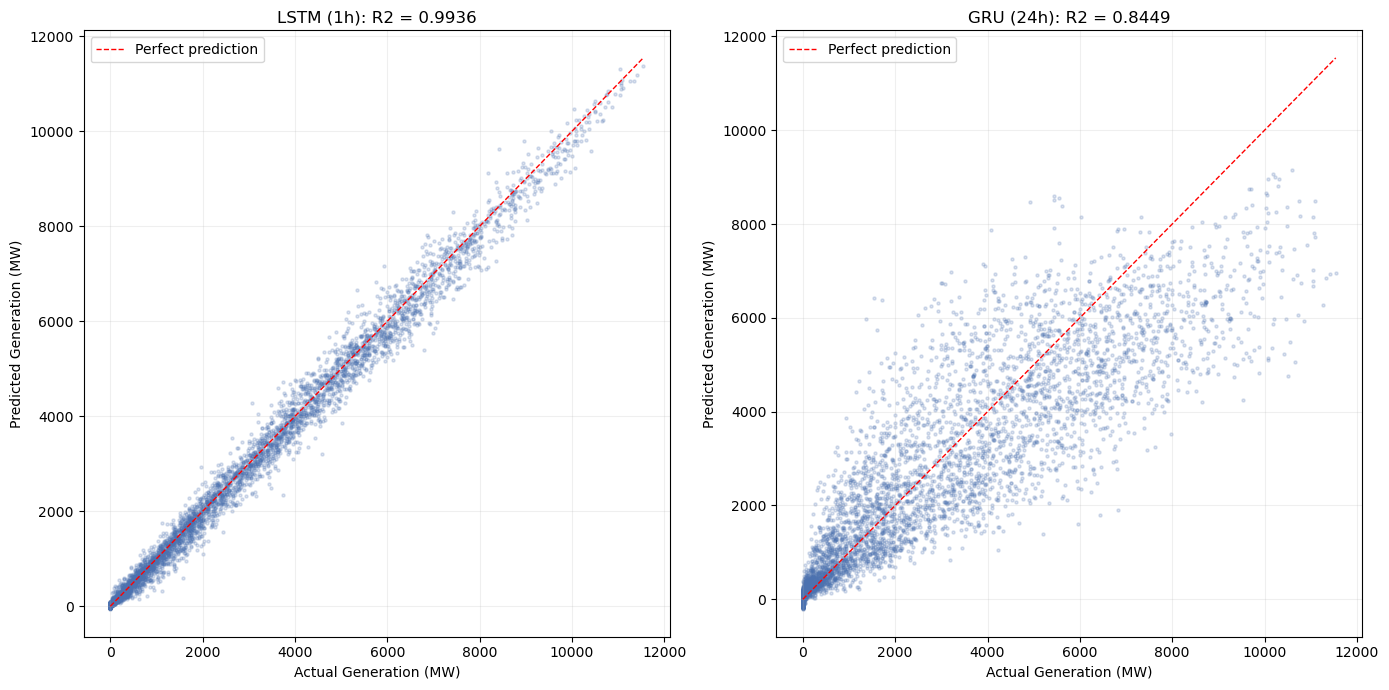

In [ ]:
#Scatter plots of predicted vs actual - recurrent models
fig, axes = plt.subplots(1, 2, figsize=(14,7))

for ax, result, horizon in [(axes[0], best_1h, '1h'), (axes[1], best_24h, '24h')]:
    ax.scatter(result['y_true'], result['y_pred'], color='#4C72B0', alpha=0.2, s=5)
    max_val = max(result['y_true'].max(), result['y_pred'].max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=1)
    ax.set_xlabel('Actual Generation (MW)')
    ax.set_ylabel('Predicted Generation (MW)')
    r2 = r2_score(result['y_true'], result['y_pred'])
    ax.set_title(f'{result["name"]}: R2 = {r2:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Scatter Plots of Predicted vs Actual.png"), dpi=150)
plt.show()

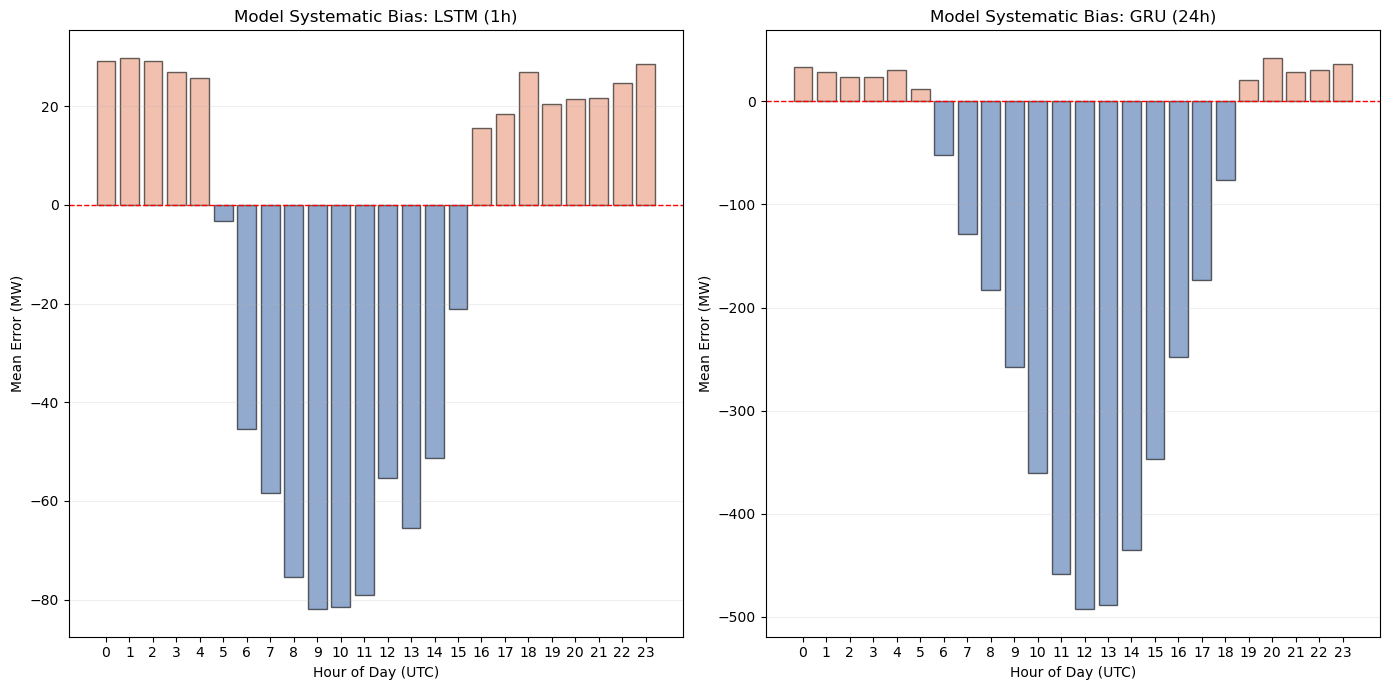

In [128]:
#Mean error by hour of day
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, result, timestamps, horizon in[(axes[0], best_1h, idx_test_1h, '1h'),
                                       (axes[1], best_24h, idx_test_24h, '24h')]:

    errors = result['y_pred'] - result['y_true']
    df_error = pd.DataFrame({'error': errors, 'hour':timestamps.hour})
    hourly_error = df_error.groupby('hour')['error'].mean()

    colors = ['#E9967A' if v >= 0 else '#4C72B0' for v in hourly_error.values]
    ax.bar(hourly_error.index, hourly_error.values, color=colors, alpha=0.6, edgecolor='black')
    ax.axhline(y=0, color='red', linewidth=1, linestyle='--')
    ax.set_xlabel('Hour of Day (UTC)')
    ax.set_ylabel('Mean Error (MW)')
    ax.set_title(f'Model Systematic Bias: {result["name"]}')
    ax.set_xticks(range(0, 24))
    ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Mean Error by Hour of Day.png"), dpi=150)
plt.show()


In [131]:
#Statistical significance tests - to confirm whether improvements are significant
#Wilcoxon signed-rank (pairwise at 1h)
print("=" * 102)
print("Wilcoxon signed-rank tests (1h horizon)")
print("Null hypothesis: Median absolute error difference = 0")
print("=" * 102)

best_rec_1h = recurrent_results[best_recurrent_1h_key]
best_rec_name = best_rec_1h['name']
ae_best_rec = np.abs(best_rec_1h['y_true'] - best_rec_1h['y_pred'])

#Comparison models at 1h (8760 samples)
comparison_1h = {'Smart Persistence (1h)': persistence_1h_results,
                 'Linear Regression (1h)': lin_1h_results,
                 'XGBoost (1h)': xgb_1h_results,
                 'Random Forest (1h)': rf_1h_results,}

comparison_1h[best_dnn_1h_key] = dnn_results[best_dnn_1h_key]

print(f"\nReference model: {best_rec_name}")
print(f"{'Comparison Model':<30} {'Median AE Ref':>15} {'Median AE Comp':>15} "
      f"{'Statistics':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 100)

for comp_name, comp_result in comparison_1h.items():
    ae_comp = np.abs(comp_result['y_true'] - comp_result['y_pred'])
    stat, pval = wilcoxon(ae_best_rec, ae_comp)
    sig = "Yes (p<0.05)" if pval < 0.05 else "No"
    print(f"{comp_name:<30} {np.median(ae_best_rec):>15.2f} {np.median(ae_comp):>15.2f} "
          f"{stat:>12.0f} {pval:>12.4e} {sig:>12}")
    
#Wilcoxon signed-rank (pairwise at 24h)
print(f"\n{'=' * 102}")
print("Wilcoxon signed-rank tests (24h horizon)")
print("=" * 102)

best_rec_24h = recurrent_results[best_recurrent_24h_key]
best_rec_24h_name = best_rec_24h['name']
ae_best_rec_24h = np.abs(best_rec_24h['y_true'] - best_rec_24h['y_pred'])

#For 24h, baselines/ML/DNN have 8760 samples but recurrent has 8737 samples
#Align by trimming the first 23 elements from baselines/ML/DNN predictions
OFFSET_24H = len(persistence_idx) - len(idx_test_24h)

comparison_24h = {
    'Smart Persistence (24h)': persistence_24h_results,
    'Linear Regression (24h)': lin_24h_results,
    'XGBoost (24h)': xgb_24h_results,
    'Random Forest (24h)': rf_24h_results,
}

comparison_24h[best_dnn_24h_key] = dnn_results[best_dnn_24h_key]

print(f"\nReference model: {best_rec_24h_name}")
print(f"Alignment: Trimming first {OFFSET_24H} samples from baseline/ML/DNN for paired comparison")
print(f"{'Comparison Model':<30} {'Median AE Ref':>15} {'Median AE Comp':>15} "
      f"{'Statistics':>12} {'p-value':>12} {'Significant':>12}")
print("-" * 102)

for comp_name, comp_result in comparison_24h.items():
    ae_comp_full = np.abs(comp_result['y_true'] - comp_result['y_pred'])
    ae_comp_aligned = ae_comp_full[OFFSET_24H:]
    stat, pval = wilcoxon(ae_best_rec_24h, ae_comp_aligned)
    sig = "Yes (p<0.05)" if pval < 0.05 else "No"
    print(f"{comp_name:<30} {np.median(ae_best_rec_24h):>15.2f} "
          f"{np.median(ae_comp_aligned):>15.2f} "
          f"{stat:>12.0f} {pval:>12.4e} {sig:>12}")

#Kruskal_wallis across regimes - RQ3
print(f"\n{'=' * 102}")
print("Kruskal-Wallis test: Across the regimes do errors differ? (RQ3)")
print("Null hypothesis: Median absolute errors are equal across Low/Moderate/High")
print("=" * 102)

kw_models = {}
kw_models[best_rec_name] = (best_rec_1h, idx_test_1h)
kw_models['XGBoost (1h)'] = (xgb_1h_results, persistence_idx)
kw_models['Smart Persistence (1h)'] = (persistence_1h_results, persistence_idx)

print(f"\n{'Model':<30} {'H-statistic':>12} {'p-value':>12} {'Significant':>12}")
print("=" * 102)

for model_name, (result, timestamps) in kw_models.items():
    ae = np.abs(result['y_true'] - result['y_pred'])
    regimes = df_test.loc[timestamps, 'regime']

    ae_low = ae[regimes == 'Low (<25%)']
    ae_mod = ae[regimes == 'Moderate (25-40%)']
    ae_high = ae[regimes == 'High (> 40%)']

    stat, pval = kruskal(ae_low, ae_mod, ae_high)
    sig = "Yes (p<0.05)" if pval < 0.05 else "No"
    print(f"{model_name:<30} {stat:>12.2f} {pval:>12.4e} {sig:>12}")

    print(f" {'Low median AE:':<20} {np.median(ae_low):>8.2f} MW (n={len(ae_low)})")
    print(f" {'Moderate median AE:':<20} {np.median(ae_mod):>8.2f} MW (n={len(ae_mod)})")
    print(f" {'High median AE:':<20} {np.median(ae_high):>8.2f} MW (n={len(ae_high)})")


Wilcoxon signed-rank tests (1h horizon)
Null hypothesis: Median absolute error difference = 0

Reference model: LSTM (1h)
Comparison Model                 Median AE Ref  Median AE Comp   Statistics      p-value  Significant
----------------------------------------------------------------------------------------------------
Smart Persistence (1h)                   35.56           80.89     10798962  4.8817e-275 Yes (p<0.05)
Linear Regression (1h)                   35.56          354.98      1850755   0.0000e+00 Yes (p<0.05)
XGBoost (1h)                             35.56           11.50     16984657   1.3713e-20 Yes (p<0.05)
Random Forest (1h)                       35.56            4.16     16539765   4.9908e-29 Yes (p<0.05)
DNN-3layer (1h)                          35.56           63.97      8476824   0.0000e+00 Yes (p<0.05)

Wilcoxon signed-rank tests (24h horizon)

Reference model: GRU (24h)
Alignment: Trimming first 23 samples from baseline/ML/DNN for paired comparison
Comparison Mode

### Monte Carlo Dropout

In [133]:
#Forward passes through BiLSTM
MC_PASSES = 100

print(f"Running Monte Carlo Dropout for {MC_PASSES} passes per horizon...")
print(f"Using model: BiLSTM (training=True dropout)")

start = time.time()

mc_preds_1h = np.array([
    recurrent_models['BiLSTM_1h'](X_test_1h, training=True).numpy().flatten()
    for _ in range(MC_PASSES)
]).T

mc_preds_24h = np.array([
    recurrent_models['BiLSTM_24h'](X_test_24h, training=True).numpy().flatten()
    for _ in range(MC_PASSES)
]).T

elapsed = time.time() - start

print(f"\nTime complete for MC Dropout: {elapsed:.1f}s")
print(f"Prediction shape for 1h: {mc_preds_1h.shape} (samples x passes)")
print(f"Prediction shape for 24h: {mc_preds_24h.shape} (samples x passes)")

Running Monte Carlo Dropout for 100 passes per horizon...
Using model: BiLSTM (training=True dropout)

Time complete for MC Dropout: 104.3s
Prediction shape for 1h: (8760, 100) (samples x passes)
Prediction shape for 24h: (8737, 100) (samples x passes)


In [134]:
#Prediction intervals computation
def compute_intervals(mc_predictions_scaled, tscaler, percentiles=(5, 95)):
    """MC predictions converted from scaled to MW and interval statistics computed"""
    mc_mw = tscaler.inverse_transform(mc_predictions_scaled)
    mean_pred = mc_mw.mean(axis=1)
    lower = np.percentile(mc_mw, percentiles[0], axis=1)
    upper = np.percentile(mc_mw, percentiles[1], axis=1)
    std_pred = mc_mw.std(axis=1)
    return mean_pred, lower, upper, std_pred

mc_mean_1h, mc_lower_1h, mc_upper_1h, mc_std_1h = compute_intervals(mc_preds_1h, target_scaler)
mc_mean_24h, mc_lower_24h, mc_upper_24h, mc_std_24h = compute_intervals(mc_preds_24h, target_scaler)

#To compare with actual values (MW)
y_true_mc_1h = target_scaler.inverse_transform(y_test_1h.reshape(-1, 1)).flatten()
y_true_mc_24h = target_scaler.inverse_transform(y_test_24h.reshape(-1, 1)).flatten()

print("Prediction interval statistics (MW):")
print(f"\n1h Forecasting Horizon:")
print(f" Mean Predicted Range: [{mc_mean_1h.min():.1f}, {mc_mean_1h.max():.1f}]")
print(f" Mean Interval Width: {np.mean(mc_upper_1h - mc_lower_1h):.1f} MW")
print(f" Mean Std: {mc_std_1h.mean():.1f} MW")

print(f"\n24h Forecasting Horizon:")
print(f" Mean Predicted Range: [{mc_mean_24h.min():.1f}, {mc_mean_24h.max():.1f}]")
print(f" Mean Interval Width: {np.mean(mc_upper_24h - mc_lower_24h):.1f} MW")
print(f" Mean Std: {mc_std_24h.mean():.1f} MW")


Prediction interval statistics (MW):

1h Forecasting Horizon:
 Mean Predicted Range: [-76.6, 11494.3]
 Mean Interval Width: 811.1 MW
 Mean Std: 252.1 MW

24h Forecasting Horizon:
 Mean Predicted Range: [-280.0, 8105.8]
 Mean Interval Width: 1041.3 MW
 Mean Std: 323.7 MW


In [135]:
#PICP and PINAW metrics
def compute_picp_pinaw(y_true_mw, lower, upper, capacity):
    """Compute coverage (PICP) and sharpness (PINAW) metrics for prediction intervals."""
    covered_samples = ((y_true_mw >= lower) & (y_true_mw <= upper)).sum()
    picp = covered_samples / len(y_true_mw) * 100
    avg_width = np.mean(upper - lower)
    pinaw = avg_width / capacity * 100
    return picp, pinaw, avg_width

test_capacity = df_test['capacity_mwp'].mean()

picp_1h, pinaw_1h, width_1h = compute_picp_pinaw(y_true_mc_1h, mc_lower_1h, mc_upper_1h, test_capacity)
picp_24h, pinaw_24h, width_24h, = compute_picp_pinaw(y_true_mc_24h, mc_lower_24h, mc_upper_24h, test_capacity)

print("Monte Carlo Dropout Evaluation: PICP & PINAW")
print("=" * 65)
print(f"{'Performance Metric':<30} {'1h horizon':>15} {'24h horizon':>15}")
print("-" * 65)
print(f"{'Interval Coverage (PICP %)':<30} {picp_1h:>14.1f}% {picp_24h:>14.1f}%")
print(f"{'Normalised Width (PINAW %)':<30} {pinaw_1h:>14.2f}% {pinaw_24h:>14.1f}%")
print(f"{'Mean Width (MW)':<30} {width_1h:>15.1f} {width_24h:>15.1f}")
print(f"{'Test Capacity (MWp)':<30} {test_capacity:>15.1f} {'':>15}")

target_coverage = 90.0
for horizon_label, picp_val in [("1h", picp_1h), ("24h", picp_24h)]: 
    if picp_val < 85.0:
        print(f"\nWarning: {horizon_label} PICP ({picp_val:.1f}%) is below {target_coverage:.0f}% target.")
        print(" Intervals are too narrow. The model is overconfident.")
    elif picp_val > 95.0:
        print(f"\nNote: {horizon_label} PICP ({picp_val:.1f}%) exceeds 95%.")
        print(" Intervals are excessively wide. The model is conservative (underconfident).")
    else:
        print(f"\n{horizon_label} PICP ({picp_val:.1f}%) is within acceptable range (85-95%).")

Monte Carlo Dropout Evaluation: PICP & PINAW
Performance Metric                  1h horizon     24h horizon
-----------------------------------------------------------------
Interval Coverage (PICP %)               93.2%           69.7%
Normalised Width (PINAW %)               4.52%            5.8%
Mean Width (MW)                          811.1          1041.3
Test Capacity (MWp)                    17943.4                

1h PICP (93.2%) is within acceptable range (85-95%).

 Intervals are too narrow. The model is overconfident.


In [136]:
#Monte Carlo Dropout Regime Stratification - RQ4
print(f"Monte Carlo Dropout Regime Stratification")
print("=" * 85)

for horizon_label, y_true, lower, upper, timestamps in [('1h', y_true_mc_1h, mc_lower_1h, mc_upper_1h, idx_test_1h),
                                                        ('24h', y_true_mc_24h, mc_lower_24h, mc_upper_24h, idx_test_24h)]:

    print(f"\n--- {horizon_label.upper()} Horizon ---")
    print(f"{'Penetration Regime':<25} {'PICP':>10} {'PINAW':>10} {'Mean Width (MW)':>12} {'Hours Inside':>15} {'Total Hours (n)':>8}")
    print("-" * 90)

    regimes = df_test.loc[timestamps, 'regime']

    for regime in ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']:
        mask = (regimes == regime).values
        total_regime_samples = mask.sum()

        if total_regime_samples == 0:
            continue
        picp, pinaw, width = compute_picp_pinaw(y_true[mask], lower[mask], upper[mask], test_capacity)
        
        captured_hours = int((picp/100.0) * total_regime_samples)
        
        print(f"{regime:<25} {picp:>9.1f}% {pinaw:>9.2f}% {width:>12.1f} {captured_hours:>14} {mask.sum():>8}")

Monte Carlo Dropout Regime Stratification

--- 1H Horizon ---
Penetration Regime              PICP      PINAW Mean Width (MW)    Hours Inside Total Hours (n)
------------------------------------------------------------------------------------------
Low (<25%)                     94.4%      3.11%        557.8           2337     2475
Moderate (25-40%)              92.2%      4.26%        763.5           2201     2386
High (> 40%)                   93.0%      5.58%       1000.9           3627     3899

--- 24H Horizon ---
Penetration Regime              PICP      PINAW Mean Width (MW)    Hours Inside Total Hours (n)
------------------------------------------------------------------------------------------
Low (<25%)                     77.5%      4.50%        807.8           1918     2475
Moderate (25-40%)              67.8%      5.66%       1015.8           1608     2374
High (> 40%)                   65.8%      6.72%       1205.4           2559     3888


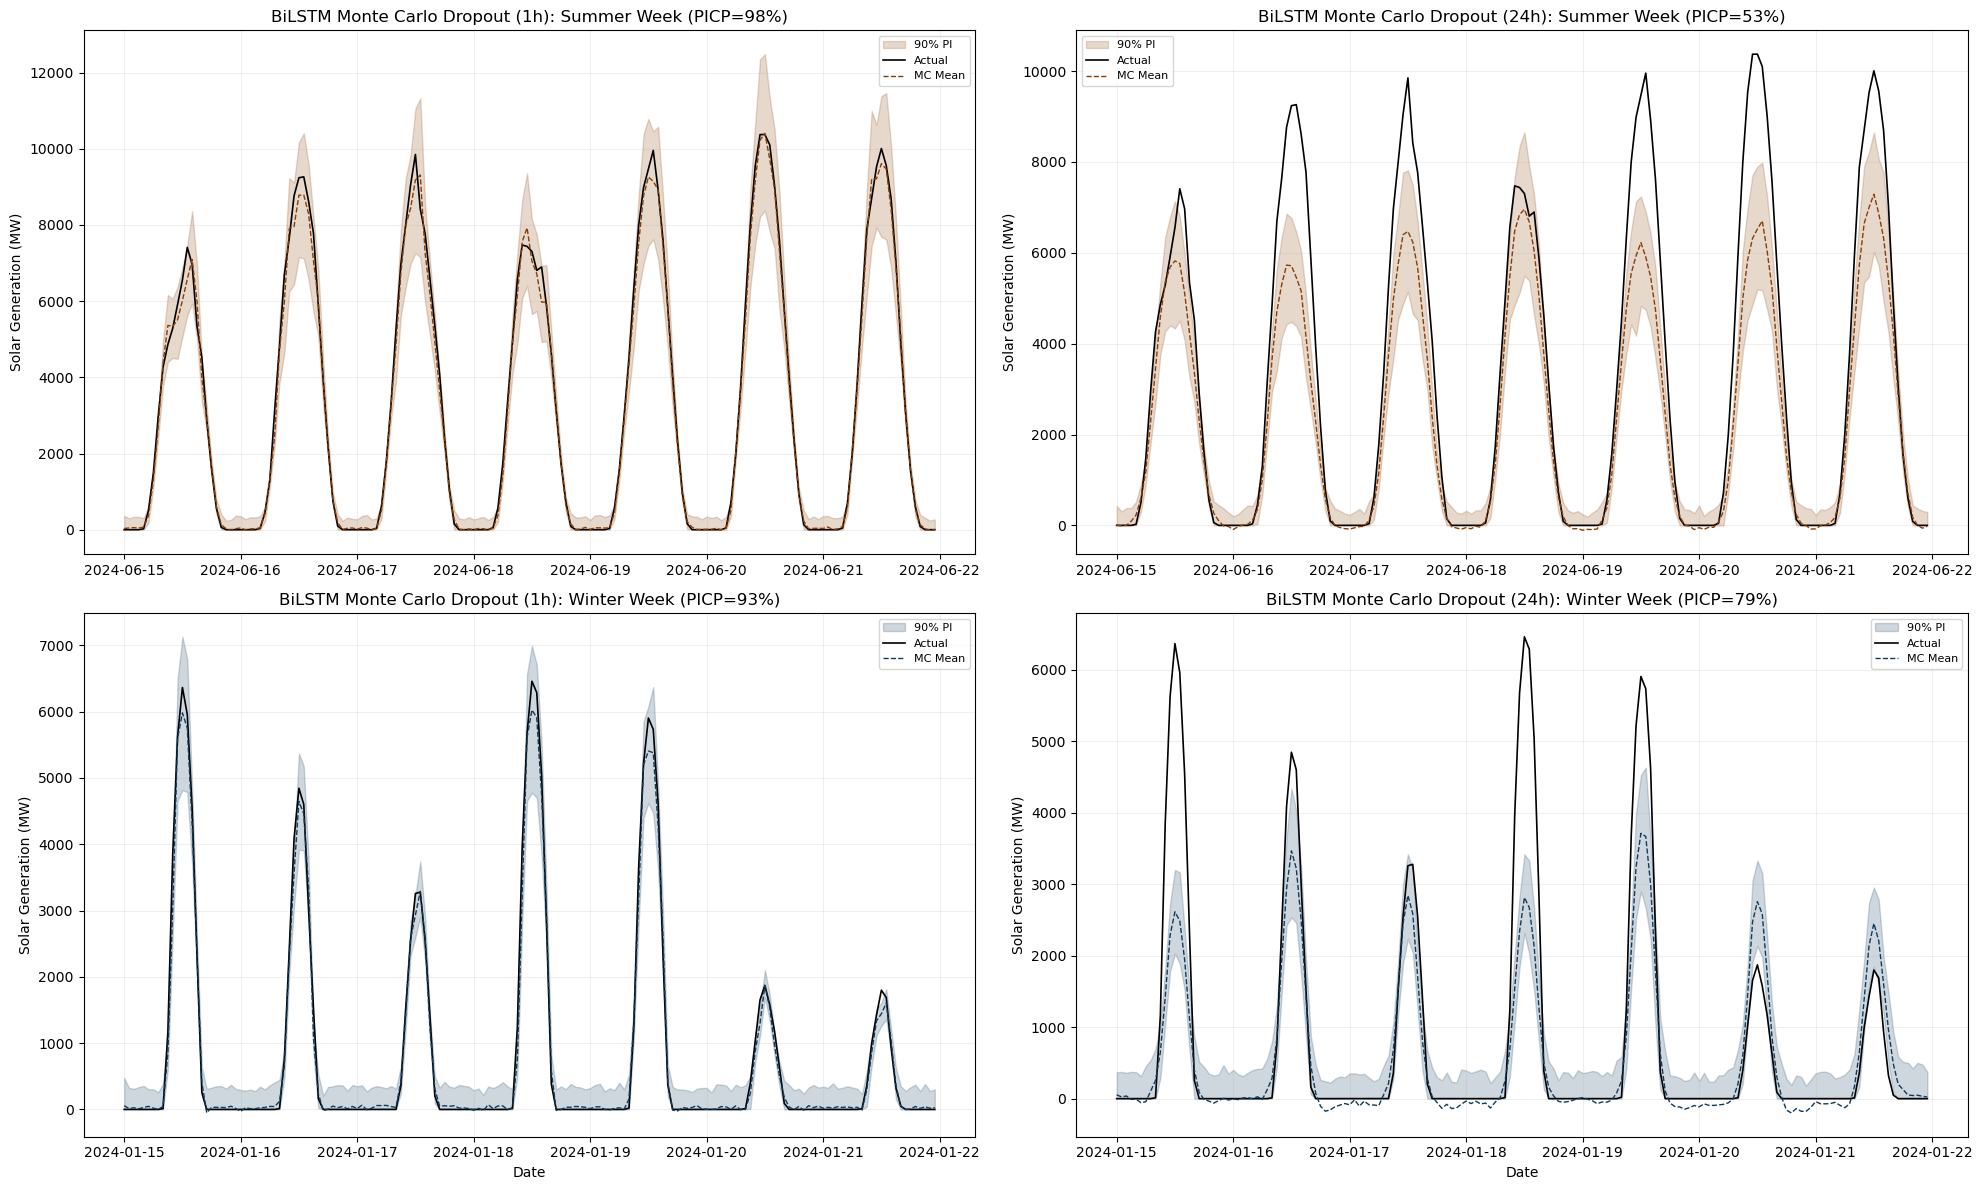

In [139]:
#Prediction interval visualisation
fig, axes = plt.subplots(2, 2, figsize=(20,12), sharex=False)

for col, (horizon_label, y_true, mc_mean, mc_lower, mc_upper, timestamps) in enumerate([
    ('1h', y_true_mc_1h, mc_mean_1h, mc_lower_1h, mc_upper_1h, idx_test_1h),
    ('24h', y_true_mc_24h, mc_mean_24h, mc_lower_24h, mc_upper_24h, idx_test_24h)]):

    for row, (season, start, end, color) in enumerate([('Summer', '2024-06-15', '2024-06-22', '#8B3D00'),
                                                       ('Winter', '2024-01-15', '2024-01-22', '#0F3B5C')]):

        ax = axes[row, col]
        mask = (timestamps >= start) & (timestamps < end)

        lower_clipped = np.maximum(mc_lower[mask], 0)

        ax.fill_between(timestamps[mask], lower_clipped, mc_upper[mask], color=color, alpha=0.2, label='90% PI')
        ax.plot(timestamps[mask], y_true[mask], color='black', linewidth=1.2, label='Actual')
        ax.plot(timestamps[mask], mc_mean[mask], color=color, linewidth=1, linestyle='--', label='MC Mean')

        covered = ((y_true[mask] >= lower_clipped) & (y_true[mask] <= mc_upper[mask])).sum()
        coverage = covered / mask.sum() * 100
        ax.set_ylabel('Solar Generation (MW)')
        ax.set_title(f'BiLSTM Monte Carlo Dropout ({horizon_label}): {season} Week (PICP={coverage:.0f}%)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)

        if row == 1:
            ax.set_xlabel('Date')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Monte Carlo Dropout Predictions Interval.png"), dpi=150)
plt.show()

### SHAP on XGBoost

In [140]:
import importlib
import shap.explainers._tree
importlib.reload(shap.explainers._tree)
import shap
importlib.reload(shap)

<module 'shap' from 'c:\\Users\\emran\\anaconda3\\Lib\\site-packages\\shap\\__init__.py'>

In [141]:
#SHAP XGBoost compatability
booster = xgb_1h.get_booster()
config = json.loads(booster.save_config())
bs = config['learner']['learner_model_param']['base_score']
print(f"XGBoost base_score: {bs} (type: {type(bs).__name__})")

try:
    test_explainer = shap.TreeExplainer(xgb_1h)
    print("SHAP TreeExplainer created successfully.")
    del test_explainer
except Exception as e:
    print(f"Error: {e}")
    print("The manual fix to _tree.py did not take effect.")
    print("Reopen the file and verify the edit was saved.")

XGBoost base_score: [1.4312538E3] (type: str)
SHAP TreeExplainer created successfully.


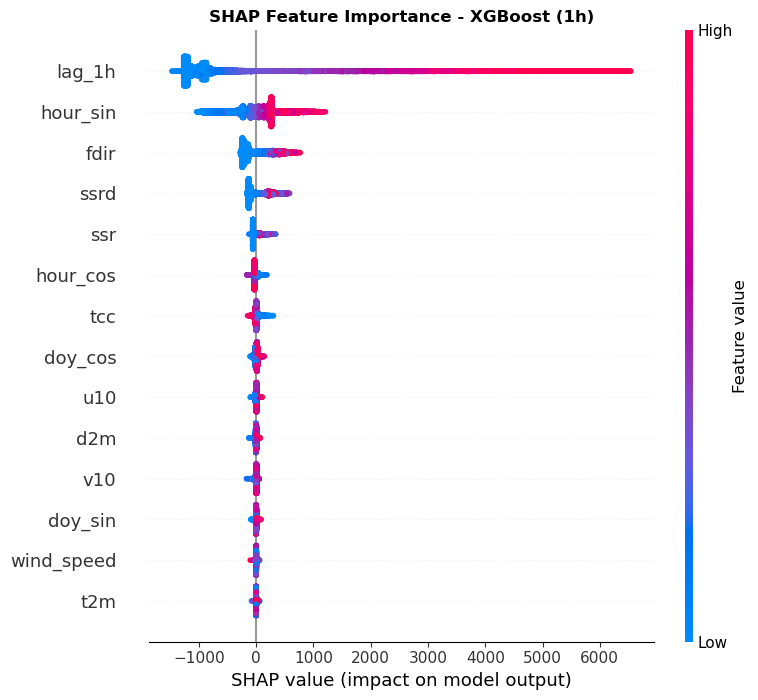

Global SHAP Importance Ranking - 1h:
 lag_1h          1481.4741
 hour_sin        354.4248
 fdir            238.8741
 ssrd            163.8773
 ssr             68.6807
 hour_cos        33.4228
 tcc             21.7234
 doy_cos         21.0343
 u10             10.7464
 d2m             7.9848
 v10             7.8114
 doy_sin         5.3145
 wind_speed      4.1706
 t2m             3.9971


In [142]:
#Computing SHAP on XGBoost - 1h
explainer_1h = shap.TreeExplainer(xgb_1h)
shap_values_1h = explainer_1h.shap_values(df_test.loc[persistence_idx, TABULAR_FEATURES_1H])

plt.figure(figsize=(10,7))
shap.summary_plot(shap_values_1h, df_test.loc[persistence_idx, TABULAR_FEATURES_1H], feature_names=TABULAR_FEATURES_1H, show=False)
plt.title("SHAP Feature Importance - XGBoost (1h)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "SHAP Feature Importance Summary - XGBoost (1h).png"), dpi=150, bbox_inches='tight')
plt.show()

#Mean absolute SHAP value per feature
mean_shap_1h = np.abs(shap_values_1h).mean(axis=0)
ranking_shap_1h = sorted(zip(TABULAR_FEATURES_1H, mean_shap_1h), key=lambda x: x[1], reverse=True)

print("Global SHAP Importance Ranking - 1h:")
for feature, value in ranking_shap_1h:
    print(f" {feature:<15} {value:.4f}")

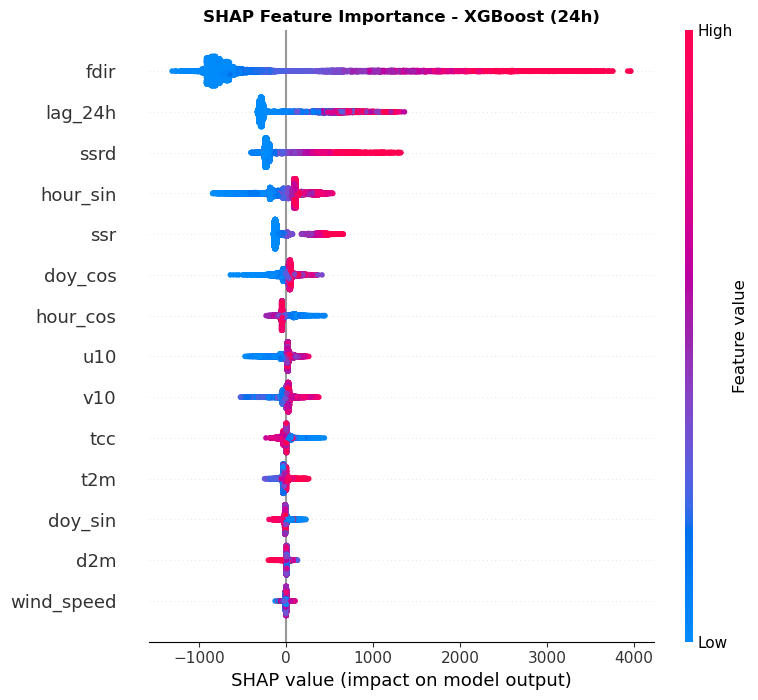

Global SHAP Importance Ranking (24h):
 fdir            950.1316
 lag_24h         392.9571
 ssrd            258.0530
 hour_sin        192.5798
 ssr             162.8752
 doy_cos         69.9055
 hour_cos        64.3194
 u10             54.4643
 v10             50.3076
 tcc             35.3875
 t2m             29.0002
 doy_sin         20.2923
 d2m             17.6659
 wind_speed      8.3688


In [143]:
#Computing SHAP on XGBoost - 24h
explainer_24h = shap.TreeExplainer(xgb_24h)
shap_values_24h = explainer_24h.shap_values(df_test.loc[persistence_idx, TABULAR_FEATURES_24H])

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_24h, df_test.loc[persistence_idx, TABULAR_FEATURES_24H], feature_names=TABULAR_FEATURES_24H, show=False)
plt.title("SHAP Feature Importance - XGBoost (24h)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "SHAP Feature Importance Summary - XGBoost (24h).png"), dpi=150, bbox_inches='tight')
plt.show()

mean_shap_24h = np.abs(shap_values_24h).mean(axis=0)
ranking_shap_24h = sorted(zip(TABULAR_FEATURES_24H, mean_shap_24h), key=lambda x: x[1], reverse=True)

print("Global SHAP Importance Ranking (24h):")
for feature, value in ranking_shap_24h:
    print(f" {feature:<15} {value:.4f}")

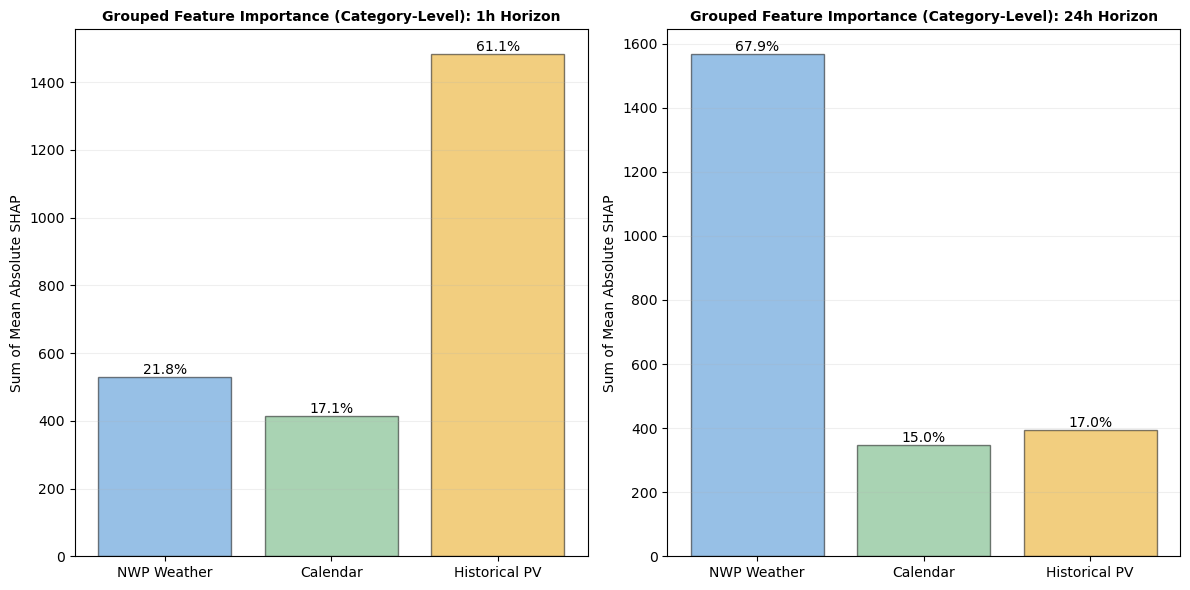

Grouped Feature Importance Shares:

1h:
 NWP Weather            527.8648 (21.78%)
 Calendar               414.1960 (17.09%)
 Historical PV         1481.4725 (61.13%)

24h:
 NWP Weather           1566.2537 (67.91%)
 Calendar               347.0973 (15.05%)
 Historical PV          392.9564 (17.04%)


In [146]:
#Grouped feature importance - RQ2
nwp_features = ['ssr', 'ssrd', 'fdir', 'd2m', 't2m', 'u10', 'v10', 'tcc', 'wind_speed']
calendar_features = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

def group_shap(shap_vals, feature_names, groups):
    """Correctly sum absolute SHAP values within each feature group."""
    grouped = {}
    for group_name, group_feats in groups.items():
        indices = [feature_names.index(f) for f in group_feats]
        grouped[group_name] = np.abs(shap_vals[:, indices]).mean(axis=0).sum()
    return grouped

groups_1h = {'NWP Weather': nwp_features, 'Calendar': calendar_features, 'Historical PV': ['lag_1h']}
groups_24h = {'NWP Weather': nwp_features, 'Calendar': calendar_features, 'Historical PV': ['lag_24h']}

grouped_1h = group_shap(shap_values_1h, TABULAR_FEATURES_1H, groups_1h)
grouped_24h = group_shap(shap_values_24h, TABULAR_FEATURES_24H, groups_24h)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, grouped, horizon_label in [(axes[0], grouped_1h, '1h'), (axes[1], grouped_24h, '24h')]:
    total = sum(grouped.values())
    percentages = {k: v / total * 100 for k, v in grouped.items()}
    bars = ax.bar(grouped.keys(), grouped.values(), color=['#3182CE', '#55A868', '#E69F00'], alpha=0.5, edgecolor='black')
    for bar, (name, pct) in zip(bars, percentages.items()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{pct:.1f}%', fontsize=10, ha='center', va='bottom')
        ax.set_ylabel('Sum of Mean Absolute SHAP')
        ax.set_title(f'Grouped Feature Importance (Category-Level): {horizon_label} Horizon', fontsize=10, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "SHAP Grouped Feature Importance (Category-Level).png"), dpi=150)
plt.show()

print("Grouped Feature Importance Shares:")
for horizon_label, grouped in [('1h', grouped_1h), ('24h', grouped_24h)]:
    total = sum(grouped.values())
    print(f"\n{horizon_label}:")
    for group_name, value in grouped.items():
        print(f" {group_name:<15} {value:>15.4f} ({value/total * 100:.2f}%)")


In [147]:
#Permutation importance - GRU
N_REPEATS = 5
rng = np.random.default_rng(SEED)

def permutation_importance_recurrent(model, X_test, y_true_mw, tscaler, feature_names, n_repeats=N_REPEATS):
    """Permutation importance across 1h and 24h horizons for 3D sequence input."""
    #Baseline prediction - RMSE
    y_pred_base = model.predict(X_test, verbose=0).flatten()
    y_pred_base_mw = y_pred_base * tscaler.scale_[0] + tscaler.mean_[0]
    baseline_rmse = np.sqrt(mean_squared_error(y_true_mw, y_pred_base_mw))

    importances = np.zeros((len(feature_names), n_repeats))

    for feat_idx, feature in enumerate(feature_names):
        for repeat in range(n_repeats):
            X_permuted = X_test.copy()
            #Generate shuffle order for samples
            perm_order = rng.permutation(len(X_permuted))
            X_permuted[:, :, feat_idx] = X_permuted[perm_order, :, feat_idx]

            y_pred_perm = model.predict(X_permuted, verbose=0).flatten()
            y_pred_perm_mw = y_pred_perm * tscaler.scale_[0] + tscaler.mean_[0]
            perm_rmse = np.sqrt(mean_squared_error(y_true_mw, y_pred_perm_mw))

            importances[feat_idx, repeat] = perm_rmse - baseline_rmse
        print(f" {feature:<15} done ({importances[feat_idx].mean():+.1f} MW)")

    return baseline_rmse, importances

print("Permutation Importance - GRU (1h)")
print(f"Baseline model: GRU_1h, {N_REPEATS} repeats per feature")
baseline_1h, perm_importances_1h = permutation_importance_recurrent(recurrent_models['GRU_1h'], 
                                                                    X_test_1h,
                                                                    y_true_mc_1h,
                                                                    target_scaler,
                                                                    RECURRENT_FEATURES)

print(f"\nPermutation Importance - GRU (24h)")
baseline_24h, perm_importances_24h = permutation_importance_recurrent(recurrent_models['GRU_24h'],
                                                                     X_test_24h,
                                                                     y_true_mc_24h,
                                                                     target_scaler,
                                                                     RECURRENT_FEATURES)

#Summary
for horizon_label, baseline, importances in [('1h', baseline_1h, perm_importances_1h),
                                            ('24h', baseline_24h, perm_importances_24h)]:
    
    print(f"\nGRU ({horizon_label}) permutation importance (baseline RMSE: {baseline:.2f} MW)")
    print(f"{'Feature':<15} {'Mean RMSE Increase':>20} {'Std':>10}")
    print("-" * 50)
    order = np.argsort(importances.mean(axis=1))[::-1]
    for feat_idx in order:
        print(f"{RECURRENT_FEATURES[feat_idx]:<15} "
              f"{importances[feat_idx].mean():>20.1f} MW "
              f"{importances[feat_idx].std():>10.1f}")

Permutation Importance - GRU (1h)
Baseline model: GRU_1h, 5 repeats per feature
 ssr             done (+148.2 MW)
 ssrd            done (+18.7 MW)
 fdir            done (+7.7 MW)
 d2m             done (+9.7 MW)
 t2m             done (+11.7 MW)
 u10             done (+3.7 MW)
 v10             done (+1.3 MW)
 tcc             done (+17.8 MW)
 wind_speed      done (+1.6 MW)
 hour_sin        done (+696.1 MW)
 hour_cos        done (+327.8 MW)
 doy_sin         done (+7.2 MW)
 doy_cos         done (+126.7 MW)
 generation_mw   done (+2746.8 MW)

Permutation Importance - GRU (24h)
 ssr             done (+184.7 MW)
 ssrd            done (+203.1 MW)
 fdir            done (+35.7 MW)
 d2m             done (+25.2 MW)
 t2m             done (+109.9 MW)
 u10             done (+14.7 MW)
 v10             done (+18.1 MW)
 tcc             done (+18.6 MW)
 wind_speed      done (+15.8 MW)
 hour_sin        done (+211.7 MW)
 hour_cos        done (+477.6 MW)
 doy_sin         done (+17.8 MW)
 doy_cos         done

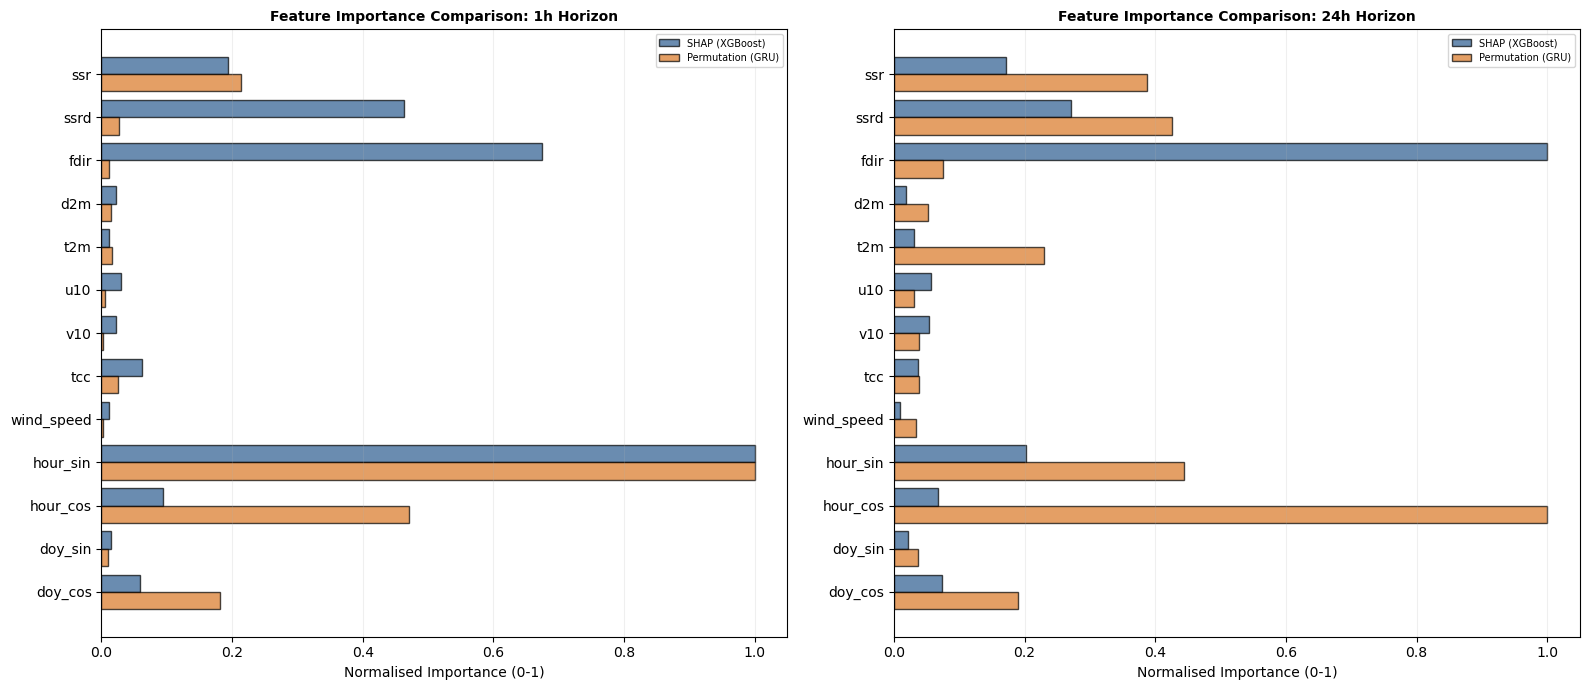

Note: lag features (XGBoost) and generation_mw (GRU) are excluded from this comparison
because they represent different mechanisms for accessing historical generation.
Normalisation is applied within the common feature set only.


In [148]:
#Comparing SHAP (XGBoost) with Permutation (GRU)
common_features = nwp_features + calendar_features

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, horizon_label, shap_vals, shap_feats, perm_imps in [(axes[0], '1h', shap_values_1h, TABULAR_FEATURES_1H, perm_importances_1h),
                                                            (axes[1], '24h', shap_values_24h, TABULAR_FEATURES_24H, perm_importances_24h)]:

    #Extract raw importances for common features only
    shap_raw = np.abs(shap_vals).mean(axis=0)
    perm_raw = perm_imps.mean(axis=1)
    perm_raw = np.clip(perm_raw, 0, None)

    shap_common = np.array([shap_raw[shap_feats.index(f)] for f in common_features])
    perm_common = np.array([perm_raw[RECURRENT_FEATURES.index(f)] for f in common_features])

    shap_common = shap_common / shap_common.max() if shap_common.max() > 0 else shap_common
    perm_common = perm_common / perm_common.max() if perm_common.max() > 0 else perm_common

    y_pos =np.arange(len(common_features))
    ax.barh(y_pos - 0.2, shap_common, 0.4, label='SHAP (XGBoost)', color='#2B5C8F', edgecolor='black', alpha=0.7)
    ax.barh(y_pos + 0.2, perm_common, 0.4, label='Permutation (GRU)', color='#D97724', edgecolor='black', alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(common_features, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Normalised Importance (0-1)')
    ax.set_title(f'Feature Importance Comparison: {horizon_label} Horizon', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "SHAP vs Permutation Importance.png"), dpi=150)
plt.show()

print("Note: lag features (XGBoost) and generation_mw (GRU) are excluded from this comparison")
print("because they represent different mechanisms for accessing historical generation.")
print("Normalisation is applied within the common feature set only.")


In [152]:
#Saving all models
import joblib

for model_key, model in recurrent_models.items():
    filename = model_key.replace(' ', '_') + '.keras'
    model.save(os.path.join(MODEL_DIR, filename))
    print(f"Saved: {filename}")

xgb_1h.save_model(os.path.join(MODEL_DIR, "Xgboost_1h.json"))
xgb_24h.save_model(os.path.join(MODEL_DIR, "Xgboost_24h.json"))

print("Saved: Xgboost_1h.json")
print("Saved: Xgboost_24h.json")

joblib.dump(rf_1h, os.path.join(MODEL_DIR, "Random_forest_1h.joblib"))
joblib.dump(rf_24h, os.path.join(MODEL_DIR, "Random_forest_24h.joblib"))

print("Saved: Random_forest_1h.joblib")
print("Saved: Random_forest_24h.joblib")

print(f"\nAll models saved to: {MODEL_DIR}")

Saved: LSTM_1h.keras
Saved: LSTM_24h.keras
Saved: BiLSTM_1h.keras
Saved: BiLSTM_24h.keras
Saved: GRU_1h.keras
Saved: GRU_24h.keras
Saved: Stacked_LSTM_1h.keras
Saved: Stacked_LSTM_24h.keras
Saved: Xgboost_1h.json
Saved: Xgboost_24h.json
Saved: Random_forest_1h.joblib
Saved: Random_forest_24h.joblib

All models saved to: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Models


In [153]:
#Exporting results tables to CSV
df_results.to_csv(os.path.join(OUTPUT_DIR, 'Model Results Master Comparison Table.csv'), index=False)
print("Saved: Model Results Master Comparison Table.csv")

df_overfit.to_csv(os.path.join(OUTPUT_DIR, "Overfitting Analysis Table.csv"), index=False)
print("Saved: Overfitting Analysis Table.csv")

mc_calibration_rows = []
for horizon_label, y_true, lower, upper, timestamps in [('1h', y_true_mc_1h, mc_lower_1h, mc_upper_1h, idx_test_1h),
                                                        ('24h', y_true_mc_24h, mc_lower_24h, mc_upper_24h, idx_test_24h)]:
    
    regimes = df_test.loc[timestamps, 'regime']

    picp, pinaw, width = compute_picp_pinaw(y_true, lower, upper, test_capacity)
    mc_calibration_rows.append({'horizon': horizon_label,
                                'regime': 'All',
                                'picp': picp,
                                'pinaw': pinaw,
                                'width_mw': width,
                                'n': len(y_true)})
    
    for regime in ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']:
        mask = (regimes == regime).values
        picp, pinaw, width = compute_picp_pinaw(y_true[mask], lower[mask], upper[mask], test_capacity)
        mc_calibration_rows.append({'horizon': horizon_label,
                                    'regime': regime,
                                    'picp': picp,
                                    'pinaw': pinaw,
                                    'width_mw': width,
                                    'n': mask.sum()})

df_mc_calibration = pd.DataFrame(mc_calibration_rows)
df_mc_calibration.to_csv(os.path.join(OUTPUT_DIR, "Monte Carlo Dropout Calibration.csv"), index=False)
print("Saved: Monte Carlo Dropout Calibration.csv")

print(f"\nAll results exported to: {OUTPUT_DIR}")

Saved: Model Results Master Comparison Table.csv
Saved: Overfitting Analysis Table.csv
Saved: Monte Carlo Dropout Calibration.csv

All results exported to: C:\Users\emran\Desktop\UCL\Dissertation\Datasets\Processed


In [20]:
#Re-run from saved CSV
df_results =pd.read_csv(os.path.join(OUTPUT_DIR, 'Model Results Master Comparison Table.csv'))

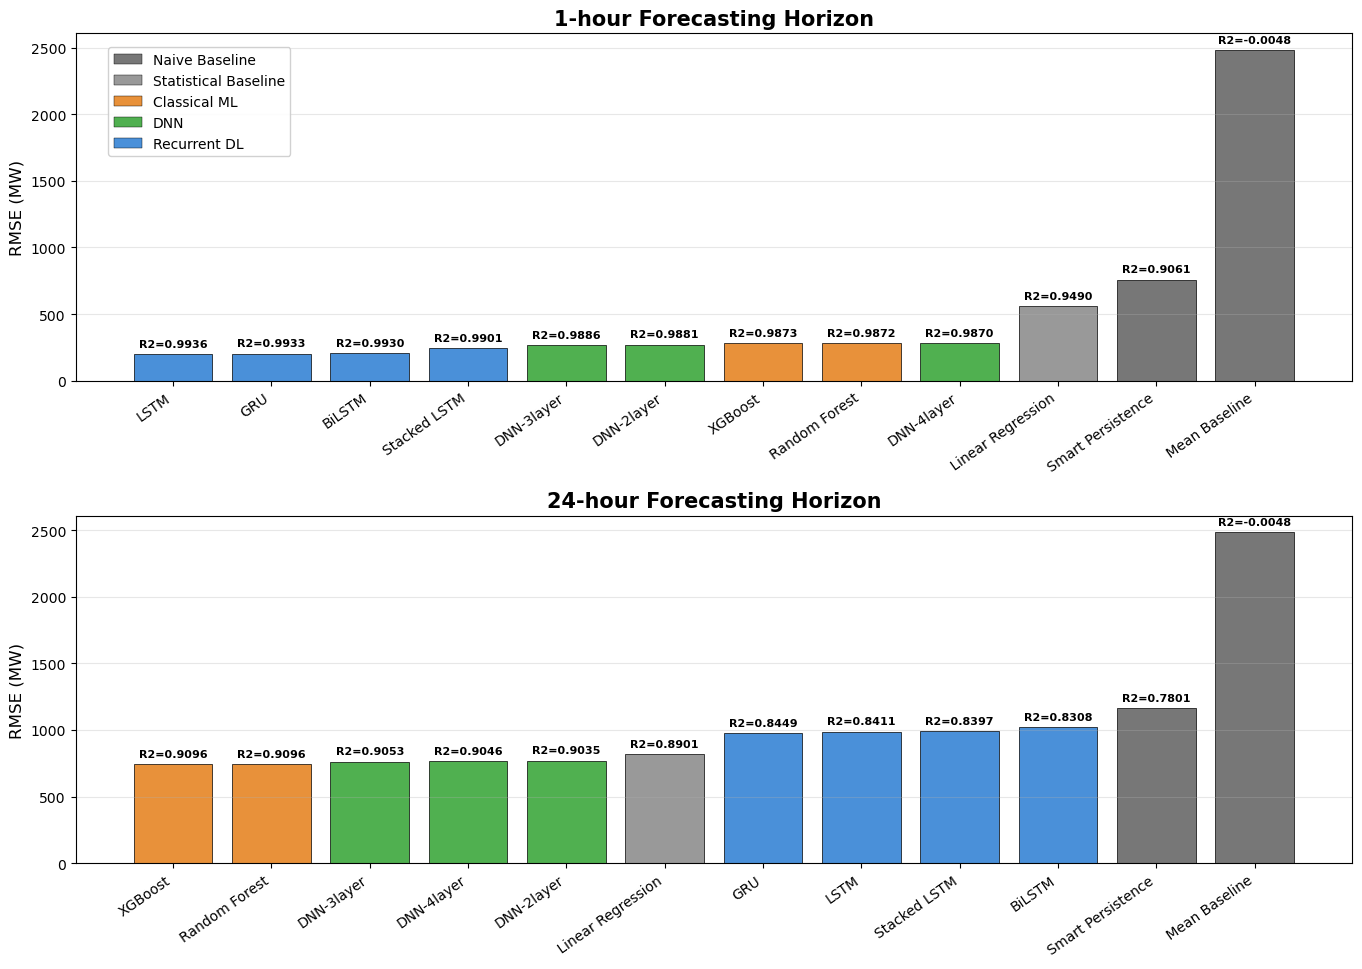

In [32]:
#Plot for model coparison
tier_colours = {'Naive Baseline':'#777777',
                'Statistical Baseline': '#999999',
                'Classical ML': '#E8913A',
                'DNN': '#50B050',
                'Recurrent DL':'#4A90D9'}

fig, axes = plt.subplots(2, 1, figsize=(14,10))

for ax, horizon_label, title in zip(axes, ['1h', '24h'], ['1-hour Forecasting Horizon', '24-hour Forecasting Horizon']):
    subset = df_results[df_results['horizon'] == horizon_label].sort_values('rmse')
    colours = [tier_colours[t] for t in subset ['tier']]
    short_names = [n.replace(f' ({horizon_label})', '') for n in subset['name']]

    bars = ax.bar(range(len(subset)), subset['rmse'], color=colours, linewidth=0.5, edgecolor='black')

    ylim = ax.get_ylim()
    height = ylim[1] - ylim[0]

    for i, (rmse_val, r2_val) in enumerate(zip(subset['rmse'], subset['r2'])):
        label = f'R2={r2_val:.4f}'
        y_text = rmse_val + 0.015 * height
        va='top'

        if y_text < ylim[0] + 0.02 * height:
            y_text = rmse_val + 0.03 * height
            va='bottom'
        ax.text(i, y_text, label, ha='center', va='bottom', rotation=0, fontsize=8, fontweight='bold', clip_on=True)

        ax.set_xticks(range(len(subset)))
        ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=10)
        ax.set_ylabel('RMSE (MW)', fontsize=12)
        ax.set_title(title, fontsize=15, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=t, linewidth=0.3)
                   for t, c in tier_colours.items()]

axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.98), fontsize=10, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 0.98, 0.98])
plt.savefig('Figures of Model Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
#Re-run from saved model
recurrent_models = {}

for arch_name in recurrent_builds.keys():
    for horizon in ['1h', '24h']:
        model_key = f"{arch_name}_{horizon}"
        filename = model_key.replace(' ', '_') + '.keras'
        filepath = os.path.join(MODEL_DIR, filename)

        recurrent_models[model_key] = keras.models.load_model(filepath)
        print(f"Loaded: {filename}, key: '{model_key}'")

print(f"\nAll recurrent models loaded: {list(recurrent_models.keys())}")
print(f"Total models: {len(recurrent_models)}")

Loaded: LSTM_1h.keras, key: 'LSTM_1h'
Loaded: LSTM_24h.keras, key: 'LSTM_24h'
Loaded: BiLSTM_1h.keras, key: 'BiLSTM_1h'
Loaded: BiLSTM_24h.keras, key: 'BiLSTM_24h'
Loaded: GRU_1h.keras, key: 'GRU_1h'
Loaded: GRU_24h.keras, key: 'GRU_24h'
Loaded: Stacked_LSTM_1h.keras, key: 'Stacked LSTM_1h'
Loaded: Stacked_LSTM_24h.keras, key: 'Stacked LSTM_24h'

All recurrent models loaded: ['LSTM_1h', 'LSTM_24h', 'BiLSTM_1h', 'BiLSTM_24h', 'GRU_1h', 'GRU_24h', 'Stacked LSTM_1h', 'Stacked LSTM_24h']
Total models: 8


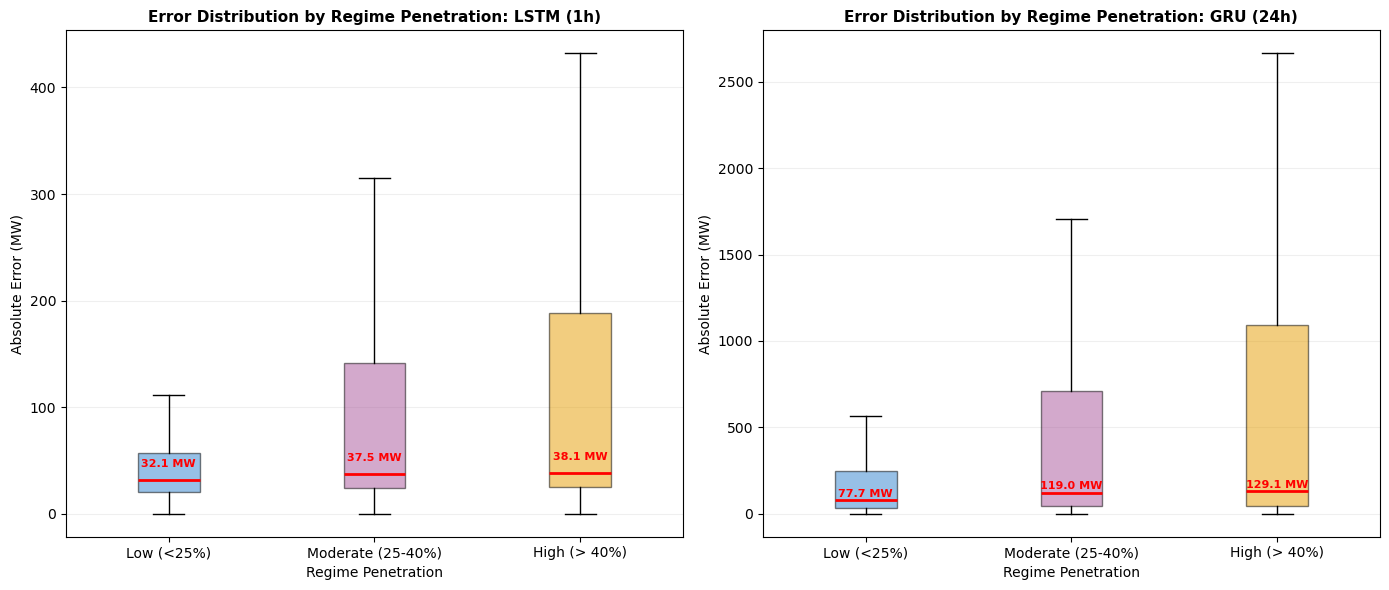

In [40]:
#Boxplot cell
regime_order = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
colours_box = ["#3182CED5", "#A8559ACF", "#E69D00CC"]

models_boxplot = {
    'LSTM (1h)': {'y_true': recurrent_results['LSTM_1h']['y_true'],
                  'y_pred': recurrent_results['LSTM_1h']['y_pred'],
                  'regimes': df_test.loc[idx_test_1h, 'regime'].values},
    'GRU (24h)': {'y_true': recurrent_results['GRU_24h']['y_true'],
                  'y_pred': recurrent_results['GRU_24h']['y_pred'],
                  'regimes': df_test.loc[idx_test_24h, 'regime'].values}
                  }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (model_label, data) in zip(axes, models_boxplot.items()):
    ae = np.abs(data['y_true'] - data['y_pred'])
    data_by_regime = [ae[data['regimes'] == r] for r in regime_order]

    bp = ax.boxplot(data_by_regime, labels=regime_order, patch_artist=True, showfliers=False, medianprops=dict(color='red', linewidth=2))

    for patch, colour in zip(bp['boxes'], colours_box):
        patch.set_facecolor(colour)
        patch.set_alpha(0.5)
    
    for i, regime_data in enumerate(data_by_regime):
        median_val = np.median(regime_data)
        ax.text(i + 1, median_val + 10, f'{median_val:.1f} MW', ha='center', va='bottom', color='red', fontsize=8, fontweight='bold')
        ax.set_xlabel('Regime Penetration', fontsize=10)
        ax.set_ylabel('Absolute Error (MW)', fontsize=10)
        ax.set_title(f'Error Distribution by Regime Penetration: {model_label}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Boxplot of Error Distribution by Regime Penetration.png'), dpi=150, bbox_inches='tight')
plt.show()

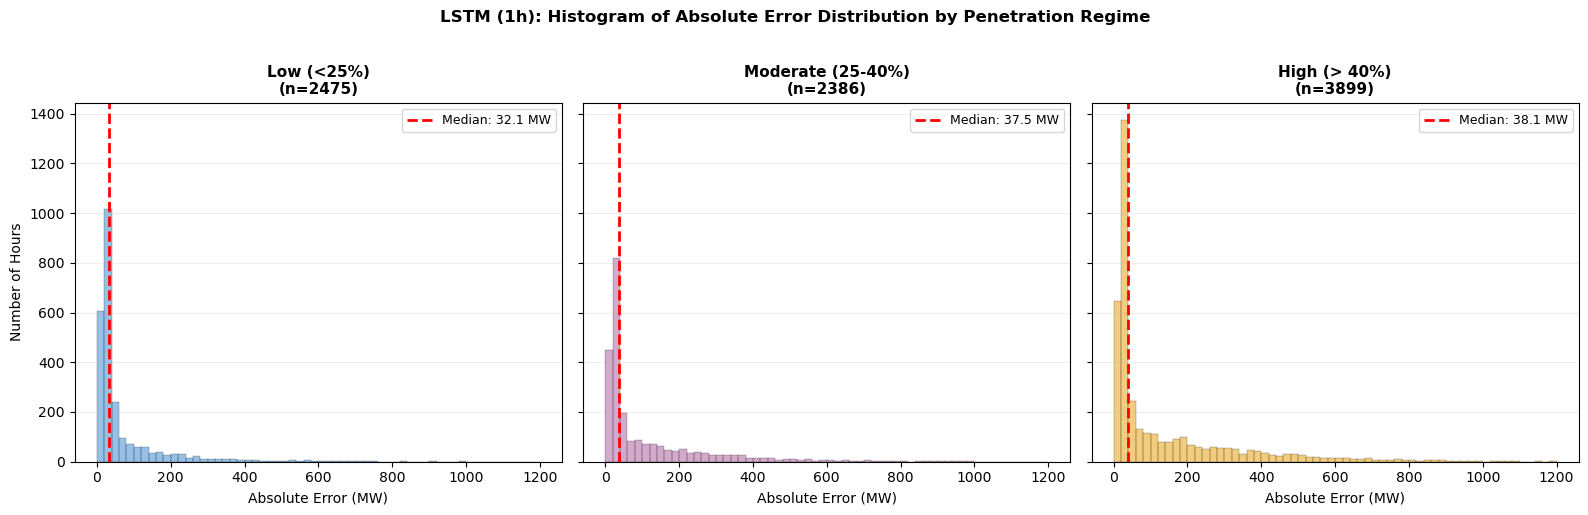

In [47]:
#Histogram of error distribution by regime (1h)
ae_lstm_1h = np.abs(recurrent_results['LSTM_1h']['y_true'] - recurrent_results['LSTM_1h']['y_pred'])
regimes_1h = df_test.loc[idx_test_1h, 'regime'].values
regime_order = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
colours_hist = ['#3182CED5', '#A8559ACF', '#E69D00CC']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, regime, colour in zip(axes, regime_order, colours_hist):
    errors = ae_lstm_1h[regimes_1h == regime]

    ax.hist(errors, bins=60, color=colour, linewidth=0.3, alpha=0.5, edgecolor='black', range=(0, 1200))
    median_val = np.median(errors)
    ax.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f} MW')
    ax.set_xlabel('Absolute Error (MW)', fontsize=10)
    ax.set_title(f'{regime}\n(n={len(errors)})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('Number of Hours', fontsize=10)
fig.suptitle('LSTM (1h): Histogram of Absolute Error Distribution by Penetration Regime', fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Histogram of Absolute Error Distribution by Penetration Regime (1h).png'), dpi=150, bbox_inches='tight')
plt.show()

horizon            regime      picp    pinaw   width_mw    n
     1h               All 93.207763 4.520106  811.06067 8760
     1h        Low (<25%) 94.424242 3.108672  557.80150 2475
     1h Moderate (25-40%) 92.246438 4.255104  763.51040 2386
     1h      High (> 40%) 93.023852 5.578221 1000.92255 3899
    24h               All 69.657777 5.803139 1041.28050 8737
    24h        Low (<25%) 77.494949 4.502073  807.82495 2475
    24h Moderate (25-40%) 67.775906 5.661388 1015.84550 2374
    24h      High (> 40%) 65.817901 6.717916 1205.42260 3888


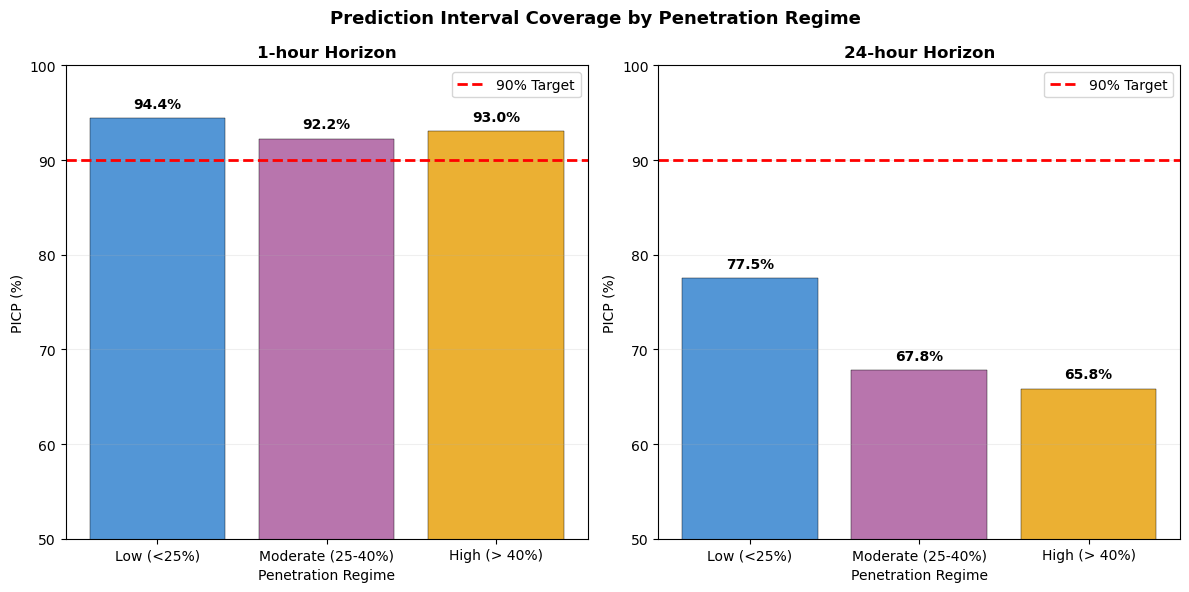

In [49]:
#Re-run from saved CSV - MC Dropout
df_mc = pd.read_csv(os.path.join(OUTPUT_DIR, 'Monte Carlo Dropout Calibration.csv'))
print(df_mc.to_string(index=False))

regime_order = ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']
picp_1h = [df_mc[(df_mc['horizon'] == '1h') & (df_mc['regime'] == r)]['picp'].values[0]
           for r in ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']]

picp_24h = [df_mc[(df_mc['horizon'] == '24h') & (df_mc['regime'] == r)]['picp'].values[0]
            for r in ['Low (<25%)', 'Moderate (25-40%)', 'High (> 40%)']]

colours_bar = ['#3182CED5', '#A8559ACF', '#E69D00CC']

fig, axes = plt.subplots(1, 2, figsize=(12,6))

for ax, picp_vals, title in zip(axes, [picp_1h, picp_24h], ['1-hour Horizon', '24-hour Horizon']):
    bars = ax.bar(regime_order, picp_vals, color=colours_bar, linewidth=0.3, edgecolor='black')
    ax.axhline(90, color='red', label='90% Target', linestyle='--', linewidth=2)

    for bar, val in zip(bars, picp_vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%', fontsize = 10, fontweight='bold', ha='center', va='bottom')
    
    ax.set_xlabel('Penetration Regime', fontsize=10)
    ax.set_ylabel('PICP (%)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(50, 100)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.2)

fig.suptitle('Prediction Interval Coverage by Penetration Regime', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'PICP by Penetration Regime.png'), dpi=150, bbox_inches='tight')
plt.show()

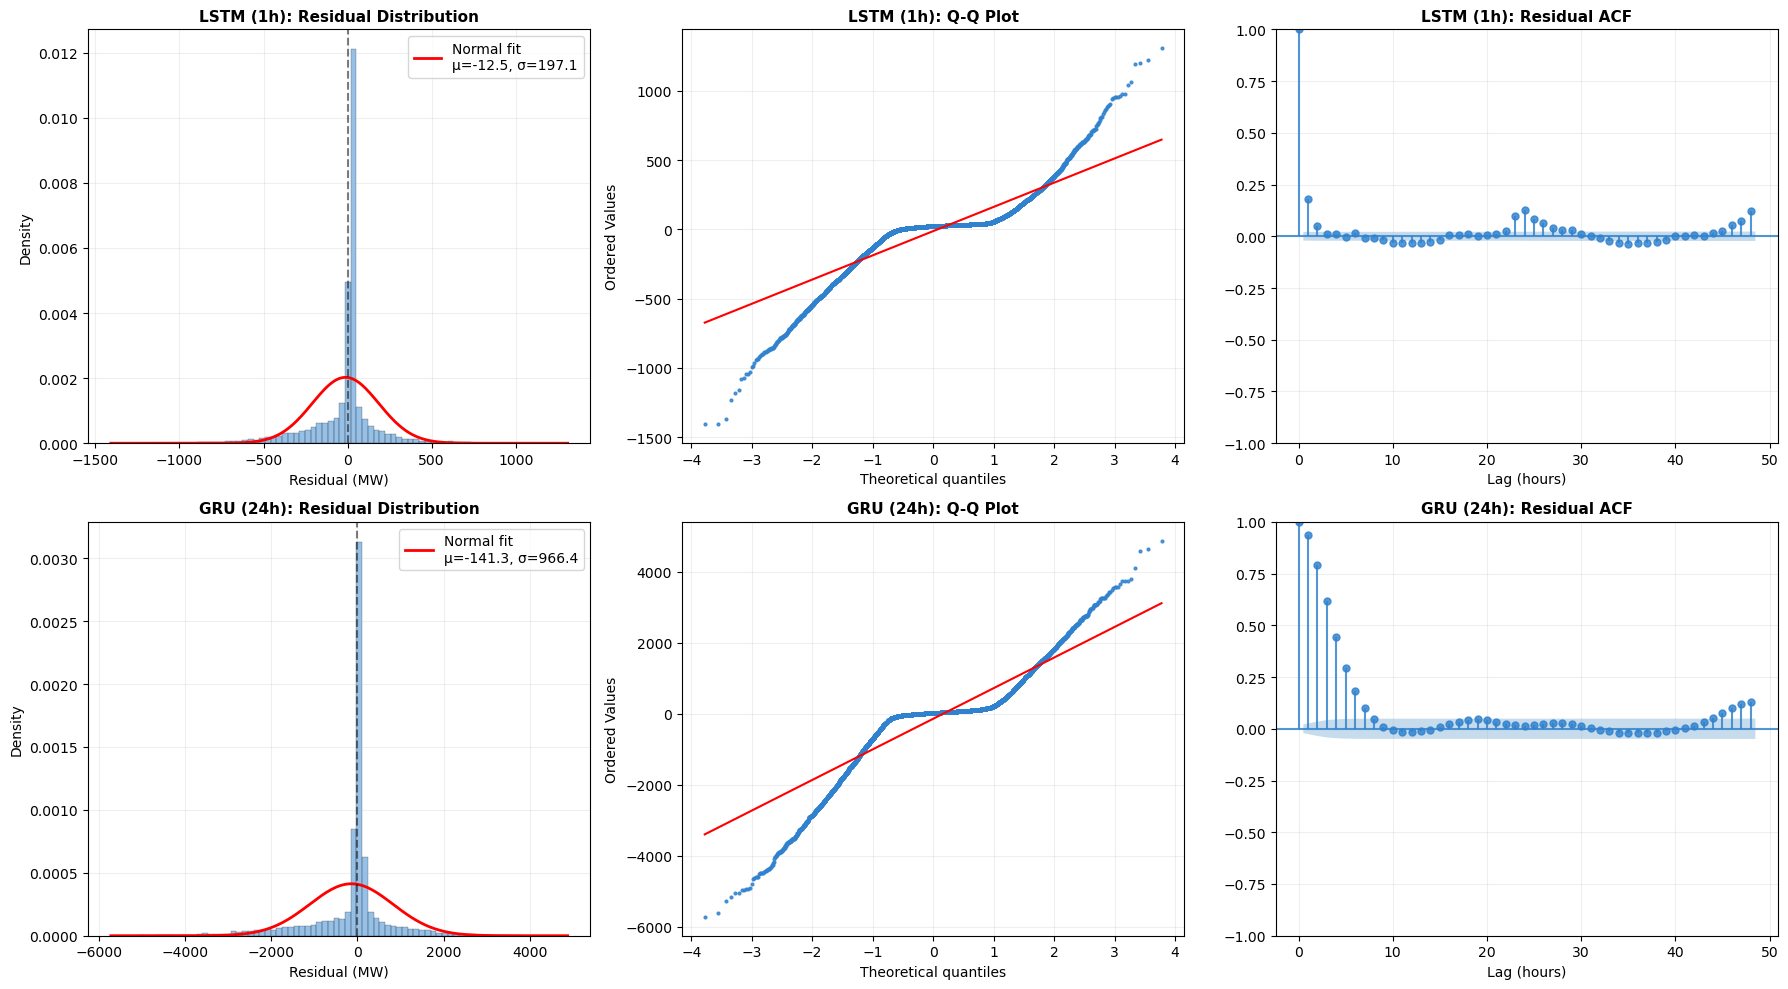


LSTM (1h) Residual Diagnostics:
 Mean: -12.48 MW
 Std: 197.12 MW
 Skewness: -0.7908
 Kurtosis: 6.9549

GRU (24h) Residual Diagnostics:
 Mean: -141.25 MW
 Std: 966.44 MW
 Skewness: -1.0568
 Kurtosis: 4.9278


In [23]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 3, figsize=(18,10))

for row, (model_key, model_label) in enumerate ([('LSTM_1h', 'LSTM (1h)'), ('GRU_24h', 'GRU (24h)')]):
    result = recurrent_results[model_key]
    residuals = result['y_pred'] - result['y_true']

    #Residual distribution
    axes[row, 0].hist(residuals, bins=80, color='#3182CED5', edgecolor='black', alpha=0.5, linewidth=0.3, density=True)
    mu, sigma = np.mean(residuals), np.std(residuals)
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    axes[row, 0].plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', linewidth=2, label=f'Normal fit\n\u03bc={mu:.1f}, \u03C3={sigma:.1f}')
    axes[row, 0].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[row, 0].set_xlabel('Residual (MW)', fontsize=10)
    axes[row, 0].set_ylabel('Density', fontsize=10)
    axes[row, 0].set_title(f'{model_label}: Residual Distribution', fontsize=11, fontweight='bold')
    axes[row, 0].legend(fontsize=10)
    axes[row, 0].grid(alpha=0.2)

    #Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[row, 1])
    axes[row, 1].set_title(f'{model_label}: Q-Q Plot', fontsize=11, fontweight='bold')
    axes[row, 1].grid(alpha=0.2)
    axes[row, 1].get_lines()[0].set_markersize(2)
    axes[row, 1].get_lines()[0].set_color('#3182CED5')

    #Residuals ACF
    plot_acf(residuals, lags=48, ax=axes[row, 2], alpha=0.05, color='#3182CED5', vlines_kwargs={'color': '#3182CED5'})
    axes[row, 2].set_xlabel('Lag (hours)', fontsize=10)
    axes[row, 2].set_title(f'{model_label}: Residual ACF', fontsize=11, fontweight='bold')
    axes[row, 2].grid(alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Residual Diagnostics for Best Models.png'), dpi=150, bbox_inches='tight')
plt.show()

for model_key, model_label in [('LSTM_1h', 'LSTM (1h)'), ('GRU_24h', 'GRU (24h)')]:
    result = recurrent_results[model_key]
    residuals = result['y_pred'] - result['y_true']
    print(f"\n{model_label} Residual Diagnostics:")
    print(f" Mean: {np.mean(residuals):.2f} MW")
    print(f" Std: {np.std(residuals):.2f} MW")
    print(f" Skewness: {stats.skew(residuals):.4f}")
    print(f" Kurtosis: {stats.kurtosis(residuals):.4f}")
